# Assignment 1 — NLP Classifiers for FactNews

This notebook builds and evaluates **traditional machine learning** classifiers for the **FactNews** dataset, a Brazilian Portuguese sentence-level dataset for factuality and media-bias analysis.

This project was developed by Elton Tamele (up201908676@up.pt), Maureen Ah-shú (up201708043@up.pt), and Tomás Teixeira (up202208041@up.pt) for the Natural Language Processing course in MEIC, FEUP.

## Goals
1. Understand the dataset provenance and annotation scheme.
2. Perform exploratory data analysis (EDA).
3. Explain the pre-processing and feature representations techniques.
4. Build baselines and ML models.
5. Report evaluation metrics and conduct error analysis.
6. Compare our results with the baselines reported by the original paper.

> No CNNs, RNNs or Transformers are used here, in accordance with the assignment constraints.


## Classification tasks
This notebook works with the two formulations exposed by the **FactNews** repository:

- **Task A** - 3-class sentence classification 
  - Labels: biased, factual, quote
- **Task B** - binary factuality design classification  
  - Labels: factual, non_factual


## Dataset provenance 

According to the **FactNews** repository and the accompanying RANLP 2023 paper, the dataset:
- is in **Brazilian Portuguese**
- contains **6,191 annotated sentences**
- comes from **300 news documents** covering **100 news stories**
- uses three media outlets: **Folha de São Paulo**, **Estadão**, and **O Globo**
- covers domains such as **politics, world, sports, daily, culture, and science**
- includes sentence-level annotations for:
  - **factual spans** as 0
  - **biased spans** as 1
  - **quotes** as -1

The original paper reports the following strong baselines:
- **Sentence-level factuality prediction**: **F1 = 0.88** with fine-tuned BERT
- **Sentence-level media bias prediction**: **F1 = 0.67** with fine-tuned BERT

Since this assignment forbids deep learning architectures such as Transformers, those values are used **only as contextual reference**, not as target models.

### References
- Repository: [franciellevargas/FactNews](https://github.com/franciellevargas/FactNews)
- Paper: *Predicting Sentence-Level Factuality of News and Bias of Media Outlets* (RANLP 2023)


## Environment Preparation

In [1]:
# If needed, uncomment the next line to install dependencies.
%pip install pandas numpy matplotlib scikit-learn nltk gensim wordcloud imbalanced-learn

import re
import warnings
import nltk
nltk.download('stopwords')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from scipy.sparse import hstack, csr_matrix
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (classification_report,accuracy_score,f1_score,confusion_matrix)
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight

from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

plt.rcParams["figure.figsize"] = (10, 5)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)



Note: you may need to restart the kernel to use updated packages.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\laptop\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Load data

In [2]:
# Load data from dataset

main_path = 'data/dataset/factnews_dataset.csv'
factuality_path = 'data/dataset/factnews_dataset_factuality_design.csv'

df_main = pd.read_csv(main_path)
df_fact = pd.read_csv(factuality_path)

print("Main dataset shape:", df_main.shape)
print("Factuality-design dataset shape:", df_fact.shape)

Main dataset shape: (6191, 7)
Factuality-design dataset shape: (6191, 7)


### Column description

From inspection, both files have the same schema:

- `file`: original document identifier
- `id_sente`: sentence identifier
- `id_article`: article/story identifier
- `domain`: news domain
- `year`: publication year
- `sentences`: sentence text
- `classe`: label

The difference is in the meaning of `classe`:
- in the **main dataset** it encodes the 3-way annotation
- in the **factuality design dataset** it encodes the binary factuality design

In [3]:
display(df_main.head())
display(df_fact.head())

,file,id_sente,id_article,domain,year,sentences,classe
0,C1_Estadao_04-08-2006_05h54,1,c1e,world,2006,"""Não houve sobreviventes"", disse Okala.",-1
1,C1_Estadao_04-08-2006_05h54,2,c1e,world,2006,As vítimas do acidente foram 14 passageiros e ...,0
2,C1_Estadao_04-08-2006_05h54,3,c1e,world,2006,"O avião explodiu e se incendiou, acrescentou o...",0
3,C1_Estadao_04-08-2006_05h54,4,c1e,world,2006,"O porta-voz informou que o avião, um Soviet An...",0
4,C1_Estadao_04-08-2006_05h54,5,c1e,world,2006,"Segundo fontes aeroportuárias, os membros da t...",0


,file,id_sente,id_article,domain,year,sentences,classe
0,C1_Estadao_04-08-2006_05h54,1,c1e,world,2006,"""Não houve sobreviventes"", disse Okala.",1
1,C1_Estadao_04-08-2006_05h54,2,c1e,world,2006,As vítimas do acidente foram 14 passageiros e ...,0
2,C1_Estadao_04-08-2006_05h54,3,c1e,world,2006,"O avião explodiu e se incendiou, acrescentou o...",0
3,C1_Estadao_04-08-2006_05h54,4,c1e,world,2006,"O porta-voz informou que o avião, um Soviet An...",0
4,C1_Estadao_04-08-2006_05h54,5,c1e,world,2006,"Segundo fontes aeroportuárias, os membros da t...",0


## Pre-processing

The preprocessing used in this notebook is intentionally simple and easy to justify:

- lowercase
- remove URLs
- remove digits
- remove punctuation/special symbols
- normalize whitespace

This is a reasonable baseline for short news sentences in Portuguese.  
We avoid aggressive stemming/lemmatization here because:
1. the dataset is not extremely large,
2. some wording choices may carry bias cues,
3. simple normalization makes it easier to interpret model errors.

In [4]:
import re

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = text.replace("“", '"').replace("”", '"').replace("‘", "'").replace("’", "'")
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^\w\sÀ-ÿ\"']", " ", text)
    text = re.sub(r"_", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


for frame in (df_main, df_fact):
    frame["text_clean"] = frame["sentences"].apply(clean_text)
    frame["n_chars"] = frame["sentences"].astype(str).str.len()
    frame["n_words"] = frame["text_clean"].str.split().str.len()
    frame["n_double_quotes"] = (frame["sentences"].astype(str).str.replace("“", '"', regex=False).str.replace("”", '"', regex=False).str.count('"'))
    frame["n_single_quotes"] = (frame["sentences"].astype(str).str.replace("‘", "'", regex=False).str.replace("’", "'", regex=False).str.count("'"))
    frame["has_quotes"] = ((frame["n_double_quotes"] + frame["n_single_quotes"]) > 0).astype(int)

main_label_map = {-1: "quote", 0: "factual", 1: "biased"}
fact_label_map = {0: "factual", 1: "non_factual"}

df_main["label"] = df_main["classe"].map(main_label_map)
df_fact["label"] = df_fact["classe"].map(fact_label_map)

display(
    df_main[
        ["sentences", "text_clean", "label", "has_quotes"]
    ].head()
)

,sentences,text_clean,label,has_quotes
0,"""Não houve sobreviventes"", disse Okala.","""não houve sobreviventes"" disse okala",quote,1
1,As vítimas do acidente foram 14 passageiros e ...,as vítimas do acidente foram passageiros e trê...,factual,0
2,"O avião explodiu e se incendiou, acrescentou o...",o avião explodiu e se incendiou acrescentou o ...,factual,0
3,"O porta-voz informou que o avião, um Soviet An...",o porta voz informou que o avião um soviet ant...,factual,0
4,"Segundo fontes aeroportuárias, os membros da t...",segundo fontes aeroportuárias os membros da tr...,factual,0


## Exploratory Data Analysis

In [5]:
print("Task A - Main label distribution:")
display(df_main["label"].value_counts().rename_axis("label").reset_index(name="count"))

print("Task B - Binary factuality label distribution:")
display(df_fact["label"].value_counts().rename_axis("label").reset_index(name="count"))

Task A - Main label distribution:


,label,count
0,factual,4242
1,quote,1391
2,biased,558


Task B - Binary factuality label distribution:


,label,count
0,factual,4242
1,non_factual,1949


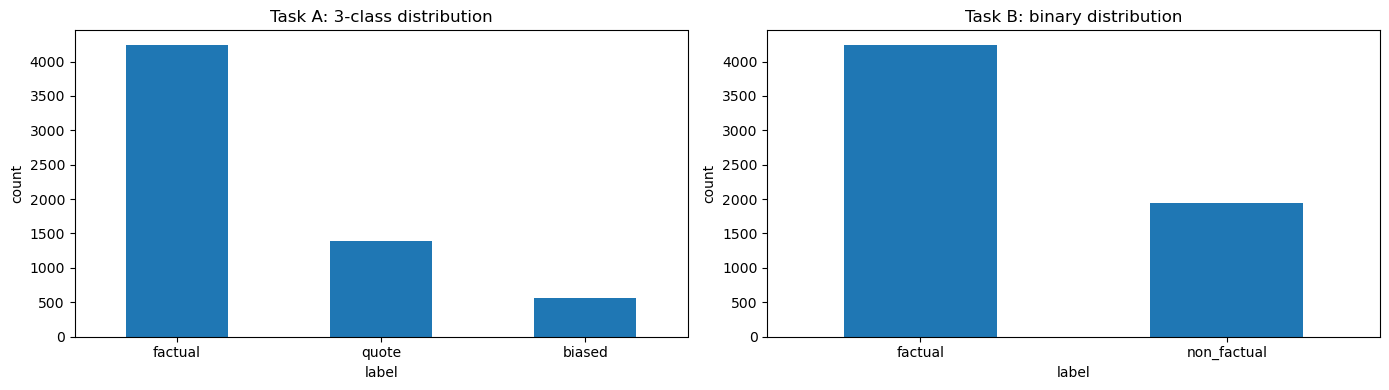

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_main["label"].value_counts().plot(kind="bar", ax=axes[0], title="Task A: 3-class distribution")
axes[0].set_xlabel("label")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=0)

df_fact["label"].value_counts().plot(kind="bar", ax=axes[1], title="Task B: binary distribution")
axes[1].set_xlabel("label")
axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Observation

The dataset is **imbalanced**:
- `factual` is clearly the majority class
- `quote` is the smallest class in Task A
- the binary task is still imbalanced

In [7]:
display(df_main["domain"].value_counts().rename_axis("domain").reset_index(name="count"))

,domain,count
0,politics,3873
1,world,880
2,sports,490
3,daily,413
4,culture,412
5,science,123


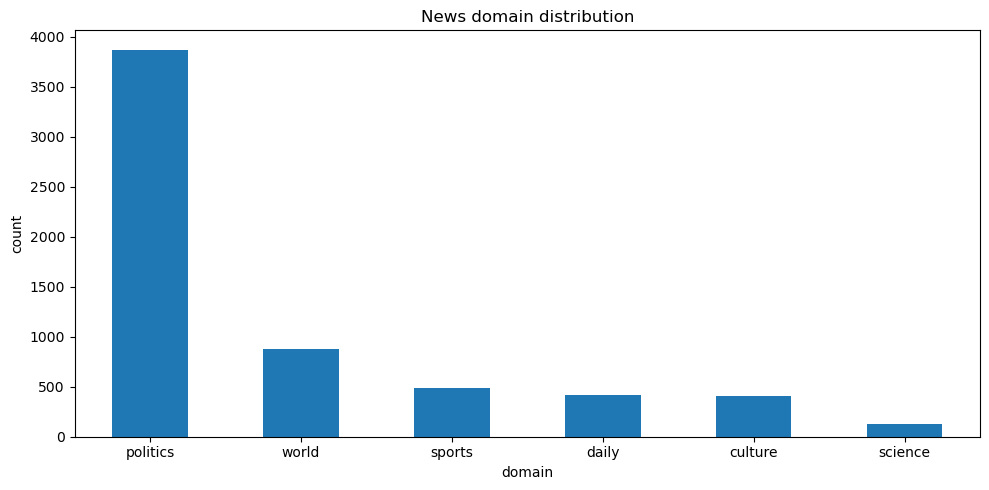

In [8]:
df_main["domain"].value_counts().plot(kind="bar", title="News domain distribution")
plt.xlabel("domain")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

`politics` dominates the corpus.  
This is important because it is specifically in political reporting that signs of bias, framing, and citation practices tend to be most common.

In [9]:
stop_words_pt = stopwords.words("portuguese")

def top_tfidf_terms_by_class(df, text_col="sentences", label_col="label", top_n=15):
    texts = df[text_col].fillna("").apply(clean_text)

    vectorizer = TfidfVectorizer(
        min_df=5,
        max_df=0.7,
        ngram_range=(1, 2),
        stop_words=stop_words_pt,
        sublinear_tf=True
    )

    X = vectorizer.fit_transform(texts)
    vocab = np.array(vectorizer.get_feature_names_out())

    results = {}
    for label in sorted(df[label_col].unique()):
        idx = (df[label_col] == label).to_numpy()

        class_mean = np.asarray(X[idx].mean(axis=0)).ravel()
        other_mean = np.asarray(X[~idx].mean(axis=0)).ravel()
        score = class_mean - other_mean

        top_idx = score.argsort()[::-1][:top_n]

        results[label] = pd.DataFrame({
            "term": vocab[top_idx],
            "class_tfidf": class_mean[top_idx],
            "other_tfidf": other_mean[top_idx],
            "distinctive_score": score[top_idx]
        })

    return results

top_terms = top_tfidf_terms_by_class(df_main, top_n=10)

for label, table in top_terms.items():
    print(f"Top terms for class: {label}")
    display(table)

Top terms for class: biased


,term,class_tfidf,other_tfidf,distinctive_score
0,moro,0.010102,0.002076,0.008027
1,kaká,0.008033,0.000215,0.007818
2,discurso,0.008283,0.001576,0.006707
3,campanha,0.009895,0.003370,0.006525
4,torcida,0.006435,0.000370,0.006065
5,seleção,0.007006,0.001013,0.005994
6,bolsonaro,0.016705,0.010886,0.005819
7,minutos,0.006723,0.001021,0.005702
8,equador,0.006109,0.000454,0.005654
9,maracanã,0.006032,0.000403,0.005629


Top terms for class: factual


,term,class_tfidf,other_tfidf,distinctive_score
0,segundo,0.012686,0.004821,0.007865
1,feira,0.010013,0.002837,0.007176
2,mil,0.007261,0.001222,0.006039
3,ano,0.008726,0.002957,0.005769
4,nesta,0.007795,0.002466,0.005329
5,votos,0.006205,0.001718,0.004487
6,pesquisa,0.005839,0.001893,0.003946
7,terça,0.004617,0.000714,0.003903
8,bilhões,0.004208,0.000425,0.003783
9,após,0.006856,0.003136,0.003720


Top terms for class: quote


,term,class_tfidf,other_tfidf,distinctive_score
0,disse,0.027730,0.005862,0.021868
1,afirmou,0.018099,0.003777,0.014323
2,gente,0.010128,0.000000,0.010128
3,porque,0.010319,0.001504,0.008815
4,vida,0.009441,0.000985,0.008456
5,sempre,0.008862,0.000796,0.008066
6,tudo,0.008093,0.000307,0.007786
7,agora,0.010578,0.003108,0.007470
8,vamos,0.007214,0.000050,0.007164
9,todos,0.008947,0.002428,0.006519


### Observation

The TF-IDF tables above are not a full linguistic analysis, but they are useful for spotting:
- Subjective and persuasive language in the biased class
    - Frequent terms such as “gente”, “vamos”, “sempre”, and “todos” suggest generalizations, inclusivity strategies, and rhetorical framing typical of opinionated discourse.
- Structured, evidence-based language in the factual class
    - Terms like “segundo”, “pesquisa”, “votos”, “bilhões”, and “mil” point to data-driven reporting, with references to sources, statistics, and measurable quantities.
- Entity-heavy and context-specific vocabulary in the quote class
    - Named entities like “moro”, “kaká”, and “bolsonaro”, along with terms such as “discurso”, “campanha”, and “maracanã”, suggest that this class is strongly tied to specific people, events, and domains (e.g., politics and sports).

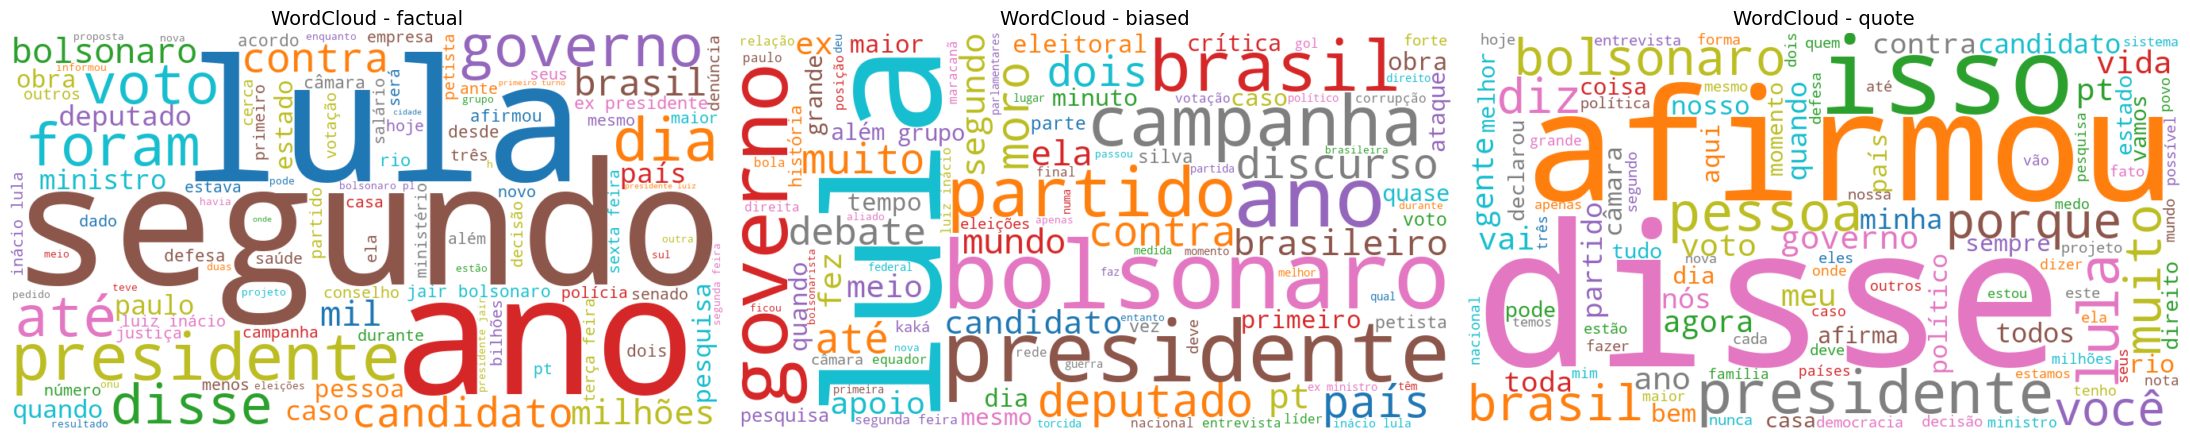

In [10]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

stopwords_pt = set(STOPWORDS)
stopwords_pt.update([
    "a", "o", "os", "as", "de", "do", "da", "dos", "das",
    "e", "é", "em", "um", "uma", "uns", "umas",
    "para", "por", "com", "sem", "no", "na", "nos", "nas",
    "ao", "aos", "à", "às", "que", "se", "como", "mais",
    "mas", "ou", "foi", "ser", "tem", "há", "já", "outro",
    "pelo", "pela", "após", "está", "ainda", "seu", "sua", 
    "ter", "eu", "ele", "ela" "isso", "não", "esse", "essa",
    "são", "sobre", "nem", "qualquer", "todo", "era", "também",
    "entre", "depois"
])


labels = ["factual", "biased", "quote"]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, label in zip(axes, labels):
    text = " ".join(
        df_main.loc[df_main["label"] == label, "text_clean"]
        .dropna()
        .astype(str)
        .tolist()
    )

    wc = WordCloud(
        width=900,
        height=500,
        background_color="white",
        stopwords=stopwords_pt,
        max_words=100,
        colormap="tab10"
    ).generate(text)

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"WordCloud - {label}", fontsize=14)

plt.tight_layout()
plt.show()

### Observation

The word clouds reinforce the earlier TF-IDF analysis:

- **factual** sentences concentrate around more neutral and informational vocabulary, often linked to reporting, events, institutions, and quantified facts.
- **biased** sentences tend to include more evaluative or rhetorical wording, which is compatible with framing.
- **quote** sentences show strong concentration of named entities and speech-related vocabulary, which makes sense because this class is closely tied to reported speech.

Word clouds are only exploratory and is not meant to be treated as rigorous evidence on their own, but they are useful to quickly visualize lexical tendencies across classes.

## Feature Representations

In this notebook we compare two families of text representations.

### Sparse representation
**Bag-of-Words and TF-IDF**
- `CountVectorizer` is used as a simple lexical baseline.
- `TfidfVectorizer` is used with unigram and bigram variants.
- In the main experimental setup, the strongest sparse representation is **TF-IDF with `min_df=2`, `max_df=0.9`, `ngram_range=(1,2)`, and `sublinear_tf=True`**.

Sparse vectors are strong baselines for sentence classification because they preserve explicit lexical cues. This is particularly useful in this dataset, where bias and factuality are often signaled by specific words, short phrases, quotation patterns, and stylistic markers.

### Dense representation
**Average Word2Vec sentence embeddings**
- a Word2Vec model is trained only on the training split of the corpus
- each sentence is represented by the average of its word vectors
- this produces a fixed-size dense vector for each sentence

This representation is useful because it captures some semantic similarity beyond exact word overlap. It is still lightweight, and allows us to compare sparse lexical features against a dense embedding-based alternative.

### Models compared
The notebook evaluates:
- **DummyClassifier** as a simple baseline
- **Logistic Regression**
- **Multinomial Naive Bayes**
- **LinearSVC**
- **Logistic Regression on Word2Vec sentence embeddings**

This selection gives a good balance between interpretability, speed, and competitiveness on sparse and dense text features.

In [11]:
X_text = df_main["text_clean"]

### Sparse Vectors

The sparse feature space grows quickly with the chosen vocabulary and n-gram range.  

In practice:
- **CountVectorizer** gives a simple frequency-based space
- **TF-IDF** reweights terms by their informativeness across the corpus
- **bigrams** increase dimensionality but may capture short expressions that are useful for framing and factuality detection

In [12]:
print("Representation with sparse vectors:\n")

vectorizer = CountVectorizer(stop_words=None)
x_CountVectorizer = vectorizer.fit_transform(X_text)
print("  - CountVectorizer's shape is " + str(x_CountVectorizer.shape))

vectorizer = TfidfVectorizer(stop_words=None)
x_TfidfVectorizer = vectorizer.fit_transform(X_text)
print("  - TfidfVectorizer's shape is " + str(x_TfidfVectorizer.shape))

vectorizer = TfidfVectorizer(stop_words=None, ngram_range=(1,2)) # unigram and bigram
x_TfidfVectorizerUB = vectorizer.fit_transform(X_text)
print("  - TfidfVectorizerUB's shape is" + str(x_TfidfVectorizerUB.shape))

vectorizer = TfidfVectorizer(stop_words=None, ngram_range=(2,2)) # bigram
x_TfidfVectorizerB = vectorizer.fit_transform(X_text)
print("  - TfidfVectorizerB's shape is " + str(x_TfidfVectorizerB.shape))

Representation with sparse vectors:

  - CountVectorizer's shape is (6191, 12596)
  - TfidfVectorizer's shape is (6191, 12596)
  - TfidfVectorizerUB's shape is(6191, 71043)
  - TfidfVectorizerB's shape is (6191, 58447)


### Dense Representation

For the dense setup, we trained a small **Word2Vec** model over the training sentences and then compute one vector per sentence by averaging the vectors of its tokens.

This approach has some advantages:
- it produces a compact representation with fixed dimensionality
- it captures partial semantic similarity between words

Also has limitations:
- the dataset is relatively small for training very rich embeddings from scratch
- averaging ignores word order

For that reason, Word2Vec is included here as a meaningful dense baseline rather than as the expected strongest model.

In [13]:
class MeanEmbeddingVectorizer(BaseEstimator, TransformerMixin):
    def __init__(self, vector_size=50, window=5, min_count=1, sg=1, epochs=8, seed=42):
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.sg = sg
        self.epochs = epochs
        self.seed = seed

    def fit(self, X, y=None):
        tokenized = [text.split() for text in X]
        self.model_ = Word2Vec(
            sentences=tokenized,
            vector_size=self.vector_size,
            window=self.window,
            min_count=self.min_count,
            workers=1,
            sg=self.sg,
            epochs=self.epochs,
            seed=self.seed,
        )
        return self

    def transform(self, X):
        vectors = np.zeros((len(X), self.vector_size))
        for i, text in enumerate(X):
            tokens = text.split()
            token_vecs = [self.model_.wv[t] for t in tokens if t in self.model_.wv]
            if token_vecs:
                vectors[i] = np.mean(token_vecs, axis=0)
        return vectors

In [14]:
w2v_demo = MeanEmbeddingVectorizer(vector_size=100, window=5, min_count=1, sg=1, epochs=15, seed=42)
X_w2v_demo = w2v_demo.fit_transform(X_text)

print("Dense representation with mean Word2Vec sentence embeddings:")
print("  - shape:", X_w2v_demo.shape)
print("  - vector size:", X_w2v_demo.shape[1])

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Dense representation with mean Word2Vec sentence embeddings:
  - shape: (6191, 100)
  - vector size: 100


## Experimental setup

To stay close to the original paper, We used:
- **80% train / 20% test**
- **stratified split**
- **random seed = 42**

The experiments are divided into two stages:
1. **without resampling** - to evaluate the models on the original class distribution
2. **with resampling** - to check whether balancing the training data improves performance

### Models

- **DummyClassifier**  
  A simple baseline. It shows how much performance is obtained by simply predicting the majority class.

- **Logistic Regression**  
  A strong and standard baseline for text classification. It works very well with sparse high-dimensional vectors.

- **Multinomial Naive Bayes**  
  A classic model for count-based text features. It is simple, efficient, and often surprisingly competitive on Bag-of-Words and TF-IDF representations.

- **LinearSVC**  
  A very strong traditional classifier for sparse text data. 

- **Logistic Regression with Word2Vec sentence embeddings**  
  This model allows us to test a dense representation while keeping the classifier simple. It is useful to compare lexical sparse features against compact semantic vectors.

### Metrics

- **precision**
- **recall**
- **F1-score per class**
- **macro-F1**
- **accuracy**

The most important metric is **macro-F1** because the dataset is imbalanced.  
Accuracy alone could hide poor performance on minority classes such as `quote`.  
Macro-F1 gives equal importance to each class and is more appropriate for comparing models in this setup.

### 1) Without Resampling

### Task A: 3-class classification (`biased`, `factual`, `quote`)

In [15]:
X_text_a = df_main["text_clean"]
X_num_a = df_main[["has_quotes", "n_chars", "n_words", "n_double_quotes", "n_single_quotes"]]
y_a = df_main["label"]

X_text_train_a, X_text_test_a, X_num_train_a, X_num_test_a, y_train_a, y_test_a = train_test_split(
    X_text_a, X_num_a, y_a, test_size=0.2, random_state=42, stratify=y_a
)

# CountVectorizer
count_vectorizer_a = CountVectorizer()
X_train_bow_a = count_vectorizer_a.fit_transform(X_text_train_a)
X_test_bow_a = count_vectorizer_a.transform(X_text_test_a)

# Binary CountVectorizer
count_vectorizer_binary_a = CountVectorizer(binary=True)
X_train_bow_binary_a = count_vectorizer_binary_a.fit_transform(X_text_train_a)
X_test_bow_binary_a = count_vectorizer_binary_a.transform(X_text_test_a)

# Scale numeric features
scaler_a = StandardScaler(with_mean=False)
X_num_train_scaled_a = scaler_a.fit_transform(X_num_train_a)
X_num_test_scaled_a = scaler_a.transform(X_num_test_a)

# Combine BoW + numeric
X_train_final_a = hstack([X_train_bow_a, X_num_train_scaled_a])
X_test_final_a = hstack([X_test_bow_a, X_num_test_scaled_a])

# Combine Binary BoW + numeric
X_train_final_binary_a = hstack([X_train_bow_binary_a, X_num_train_scaled_a])
X_test_final_binary_a = hstack([X_test_bow_binary_a, X_num_test_scaled_a])

# TF-IDF (1,2)
tfidf_vectorizer_a = TfidfVectorizer(
    min_df=2,
    max_df=0.9,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf_a = tfidf_vectorizer_a.fit_transform(X_text_train_a)
X_test_tfidf_a = tfidf_vectorizer_a.transform(X_text_test_a)

X_train_final_tfidf_a = hstack([X_train_tfidf_a, X_num_train_scaled_a])
X_test_final_tfidf_a = hstack([X_test_tfidf_a, X_num_test_scaled_a])

# TF-IDF unigram
tfidf_vectorizer_uni_a = TfidfVectorizer(
    min_df=2,
    max_df=0.9,
    ngram_range=(1, 1),
    sublinear_tf=True
)

X_train_tfidf_uni_a = tfidf_vectorizer_uni_a.fit_transform(X_text_train_a)
X_test_tfidf_uni_a = tfidf_vectorizer_uni_a.transform(X_text_test_a)

X_train_final_tfidf_uni_a = hstack([X_train_tfidf_uni_a, X_num_train_scaled_a])
X_test_final_tfidf_uni_a = hstack([X_test_tfidf_uni_a, X_num_test_scaled_a])

# TF-IDF bigram
tfidf_vectorizer_bi_a = TfidfVectorizer(
    min_df=2,
    max_df=0.9,
    ngram_range=(2, 2),
    sublinear_tf=True
)

X_train_tfidf_bi_a = tfidf_vectorizer_bi_a.fit_transform(X_text_train_a)
X_test_tfidf_bi_a = tfidf_vectorizer_bi_a.transform(X_text_test_a)

X_train_final_tfidf_bi_a = hstack([X_train_tfidf_bi_a, X_num_train_scaled_a])
X_test_final_tfidf_bi_a = hstack([X_test_tfidf_bi_a, X_num_test_scaled_a])

results_a = {}

#### Baseline

In [16]:
dummy_a = DummyClassifier(strategy="most_frequent")
dummy_a.fit(X_train_final_a, y_train_a)

y_pred_dummy_a = dummy_a.predict(X_test_final_a)

report = classification_report(y_test_a, y_pred_dummy_a, output_dict=True)
results_a['Dummy'] = {
    'accuracy':  report['accuracy'],
    'f1_macro':  report['macro avg']['f1-score'],
    'f1_biased': report.get('biased', {}).get('f1-score', 0.0)
}
print("=== Task A | DummyClassifier (most_frequent) ===")
print(classification_report(y_test_a, y_pred_dummy_a)) 

lr_binary_baseline_a = LogisticRegression(max_iter=1000)
lr_binary_baseline_a.fit(X_train_final_binary_a, y_train_a)
y_pred_lr_binary_baseline_a = lr_binary_baseline_a.predict(X_test_final_binary_a)

report = classification_report(y_test_a, y_pred_lr_binary_baseline_a, output_dict=True)
results_a['LR + Binary BoW'] = {
    'accuracy':  report['accuracy'],
    'f1_macro':  report['macro avg']['f1-score'],
    'f1_biased': report.get('biased', {}).get('f1-score', 0.0)
}
print("=== Task A | CountVectorizer(binary=True) + LogisticRegression ===")
print(classification_report(y_test_a, y_pred_lr_binary_baseline_a))

=== Task A | DummyClassifier (most_frequent) ===
              precision    recall  f1-score   support

      biased       0.00      0.00      0.00       112
     factual       0.69      1.00      0.81       849
       quote       0.00      0.00      0.00       278

    accuracy                           0.69      1239
   macro avg       0.23      0.33      0.27      1239
weighted avg       0.47      0.69      0.56      1239

=== Task A | CountVectorizer(binary=True) + LogisticRegression ===
              precision    recall  f1-score   support

      biased       0.46      0.21      0.28       112
     factual       0.85      0.94      0.89       849
       quote       0.87      0.79      0.83       278

    accuracy                           0.84      1239
   macro avg       0.73      0.64      0.67      1239
weighted avg       0.82      0.84      0.82      1239



#### Logistic Regression

In [17]:
lr_count_a = LogisticRegression(max_iter=1000)
lr_count_a.fit(X_train_final_a, y_train_a)
y_pred_lr_count_a = lr_count_a.predict(X_test_final_a)

report = classification_report(y_test_a, y_pred_lr_count_a, output_dict=True)
results_a['LR + Count'] = {
    'accuracy':  report['accuracy'],
    'f1_macro':  report['macro avg']['f1-score'],
    'f1_biased': report.get('biased', {}).get('f1-score', 0.0)
}
print("=== Task A | CountVectorizer + LogisticRegression ===")
print(classification_report(y_test_a, y_pred_lr_count_a))



lr_count_balanced_a = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_count_balanced_a.fit(X_train_final_a, y_train_a)
y_pred_lr_count_balanced_a = lr_count_balanced_a.predict(X_test_final_a)

report = classification_report(y_test_a, y_pred_lr_count_balanced_a, output_dict=True)
results_a['LR + Count (balanced)'] = {
    'accuracy':  report['accuracy'],
    'f1_macro':  report['macro avg']['f1-score'],
    'f1_biased': report.get('biased', {}).get('f1-score', 0.0)
}
print("=== Task A | CountVectorizer + LogisticRegression(class_weight='balanced') ===")
print(classification_report(y_test_a, y_pred_lr_count_balanced_a))



lr_tfidf_a = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_tfidf_a.fit(X_train_final_tfidf_a, y_train_a)
y_pred_lr_tfidf_a = lr_tfidf_a.predict(X_test_final_tfidf_a)

report = classification_report(y_test_a, y_pred_lr_tfidf_a, output_dict=True)
results_a['LR + TF-IDF (1,2)'] = {
    'accuracy':  report['accuracy'],
    'f1_macro':  report['macro avg']['f1-score'],
    'f1_biased': report.get('biased', {}).get('f1-score', 0.0)
}
print("=== Task A | TF-IDF (1,2) + LogisticRegression ===")
print(classification_report(y_test_a, y_pred_lr_tfidf_a))



lr_tfidf_balanced_a = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_tfidf_balanced_a.fit(X_train_final_tfidf_a, y_train_a)
y_pred_lr_tfidf_balanced_a = lr_tfidf_balanced_a.predict(X_test_final_tfidf_a)

report = classification_report(y_test_a, y_pred_lr_tfidf_balanced_a, output_dict=True)
results_a['LR + TF-IDF (1,2) (balanced)'] = {
    'accuracy':  report['accuracy'],
    'f1_macro':  report['macro avg']['f1-score'],
    'f1_biased': report.get('biased', {}).get('f1-score', 0.0)
}
print("=== Task A | TF-IDF (1,2) + LogisticRegression(class_weight='balanced') ===")
print(classification_report(y_test_a, y_pred_lr_tfidf_balanced_a))



lr_tfidf_uni_a = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_tfidf_uni_a.fit(X_train_final_tfidf_uni_a, y_train_a)
y_pred_lr_tfidf_uni_a = lr_tfidf_uni_a.predict(X_test_final_tfidf_uni_a)

report = classification_report(y_test_a, y_pred_lr_tfidf_uni_a, output_dict=True)
results_a['LR + TF-IDF unigram'] = {
    'accuracy':  report['accuracy'],
    'f1_macro':  report['macro avg']['f1-score'],
    'f1_biased': report.get('biased', {}).get('f1-score', 0.0)
}
print("=== Task A | TF-IDF unigram + LogisticRegression ===")
print(classification_report(y_test_a, y_pred_lr_tfidf_uni_a))



lr_tfidf_bi_a = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_tfidf_bi_a.fit(X_train_final_tfidf_bi_a, y_train_a)
y_pred_lr_tfidf_bi_a = lr_tfidf_bi_a.predict(X_test_final_tfidf_bi_a)

report = classification_report(y_test_a, y_pred_lr_tfidf_bi_a, output_dict=True)
results_a['LR + TF-IDF bigram'] = {
    'accuracy':  report['accuracy'],
    'f1_macro':  report['macro avg']['f1-score'],
    'f1_biased': report.get('biased', {}).get('f1-score', 0.0)
}
print("=== Task A | TF-IDF bigram + LogisticRegression ===")
print(classification_report(y_test_a, y_pred_lr_tfidf_bi_a))

=== Task A | CountVectorizer + LogisticRegression ===
              precision    recall  f1-score   support

      biased       0.45      0.23      0.31       112
     factual       0.85      0.93      0.89       849
       quote       0.85      0.78      0.82       278

    accuracy                           0.83      1239
   macro avg       0.72      0.65      0.67      1239
weighted avg       0.82      0.83      0.82      1239

=== Task A | CountVectorizer + LogisticRegression(class_weight='balanced') ===
              precision    recall  f1-score   support

      biased       0.37      0.36      0.37       112
     factual       0.88      0.88      0.88       849
       quote       0.81      0.83      0.82       278

    accuracy                           0.82      1239
   macro avg       0.69      0.69      0.69      1239
weighted avg       0.82      0.82      0.82      1239

=== Task A | TF-IDF (1,2) + LogisticRegression ===
              precision    recall  f1-score   support


#### Multimodal NaiveBayes

In [18]:
sample_weights_a = compute_sample_weight(class_weight='balanced', y=y_train_a)


mnb_count_a = MultinomialNB()
mnb_count_a.fit(X_train_final_a, y_train_a, sample_weight=sample_weights_a)
y_pred_mnb_count_a = mnb_count_a.predict(X_test_final_a)

report = classification_report(y_test_a, y_pred_mnb_count_a, output_dict=True)
results_a['MNB + Count (balanced)'] = {
    'accuracy':  report['accuracy'],
    'f1_macro':  report['macro avg']['f1-score'],
    'f1_biased': report.get('biased', {}).get('f1-score', 0.0)
}
print("=== Task A | CountVectorizer + MultinomialNB ===")
print(classification_report(y_test_a, y_pred_mnb_count_a))



mnb_tfidf_a = MultinomialNB()
mnb_tfidf_a.fit(X_train_final_tfidf_a, y_train_a, sample_weight=sample_weights_a)
y_pred_mnb_tfidf_a = mnb_tfidf_a.predict(X_test_final_tfidf_a)

report = classification_report(y_test_a, y_pred_mnb_tfidf_a, output_dict=True)
results_a['MNB + TF-IDF (1,2) (balanced)'] = {
    'accuracy':  report['accuracy'],
    'f1_macro':  report['macro avg']['f1-score'],
    'f1_biased': report.get('biased', {}).get('f1-score', 0.0)
}
print("=== Task A | TF-IDF (1,2) + MultinomialNB ===")
print(classification_report(y_test_a, y_pred_mnb_tfidf_a))



mnb_tfidf_uni_a = MultinomialNB()
mnb_tfidf_uni_a.fit(X_train_final_tfidf_uni_a, y_train_a, sample_weight=sample_weights_a)
y_pred_mnb_tfidf_uni_a = mnb_tfidf_uni_a.predict(X_test_final_tfidf_uni_a)

report = classification_report(y_test_a, y_pred_mnb_tfidf_uni_a, output_dict=True)
results_a['MNB + TF-IDF unigram (balanced)'] = {
    'accuracy':  report['accuracy'],
    'f1_macro':  report['macro avg']['f1-score'],
    'f1_biased': report.get('biased', {}).get('f1-score', 0.0)
}
print("=== Task A | TF-IDF unigram + MultinomialNB ===")
print(classification_report(y_test_a, y_pred_mnb_tfidf_uni_a))



mnb_tfidf_bi_a = MultinomialNB()
mnb_tfidf_bi_a.fit(X_train_final_tfidf_bi_a, y_train_a, sample_weight=sample_weights_a)
y_pred_mnb_tfidf_bi_a = mnb_tfidf_bi_a.predict(X_test_final_tfidf_bi_a)

report = classification_report(y_test_a, y_pred_mnb_tfidf_bi_a, output_dict=True)
results_a['MNB + TF-IDF bigram (balanced)'] = {
    'accuracy':  report['accuracy'],
    'f1_macro':  report['macro avg']['f1-score'],
    'f1_biased': report.get('biased', {}).get('f1-score', 0.0)
}
print("=== Task A | TF-IDF bigram + MultinomialNB ===")
print(classification_report(y_test_a, y_pred_mnb_tfidf_bi_a))



mnb_tfidf_uni_a = MultinomialNB()
mnb_tfidf_uni_a.fit(X_train_final_tfidf_uni_a, y_train_a)
y_pred_mnb_tfidf_uni_a = mnb_tfidf_uni_a.predict(X_test_final_tfidf_uni_a)

report = classification_report(y_test_a, y_pred_mnb_tfidf_uni_a, output_dict=True)
results_a['MNB + TF-IDF unigram'] = {
    'accuracy':  report['accuracy'],
    'f1_macro':  report['macro avg']['f1-score'],
    'f1_biased': report.get('biased', {}).get('f1-score', 0.0)
}
print("=== Task A | TF-IDF unigram + MultinomialNB (no class_weight) ===")
print(classification_report(y_test_a, y_pred_mnb_tfidf_uni_a))

=== Task A | CountVectorizer + MultinomialNB ===
              precision    recall  f1-score   support

      biased       0.34      0.66      0.45       112
     factual       0.92      0.74      0.82       849
       quote       0.72      0.88      0.79       278

    accuracy                           0.76      1239
   macro avg       0.66      0.76      0.69      1239
weighted avg       0.82      0.76      0.78      1239

=== Task A | TF-IDF (1,2) + MultinomialNB ===
              precision    recall  f1-score   support

      biased       0.23      0.76      0.36       112
     factual       0.94      0.64      0.76       849
       quote       0.78      0.82      0.80       278

    accuracy                           0.69      1239
   macro avg       0.65      0.74      0.64      1239
weighted avg       0.84      0.69      0.73      1239

=== Task A | TF-IDF unigram + MultinomialNB ===
              precision    recall  f1-score   support

      biased       0.26      0.72      0

### LinearSVC

In [19]:
def fit_best_linearsvc_a(model_name, X_train, X_test, y_train, y_test):
    param_grid = {
        "C": [0.01, 0.1, 1, 10],
        "class_weight": [None, "balanced"],
        "loss": ["squared_hinge"],
        "max_iter": [5000, 10000]
    }

    grid = GridSearchCV(
        estimator=LinearSVC(random_state=42),
        param_grid=param_grid,
        scoring="f1_macro",
        cv=5,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    test_accuracy = accuracy_score(y_test, y_pred)
    test_f1_macro = f1_score(y_test, y_pred, average="macro")

    print(f"\n===== {model_name} =====")
    print("Best params:", grid.best_params_)
    print("Best CV score:", grid.best_score_)
    print("Test Accuracy:", test_accuracy)
    print("Test F1 macro:", test_f1_macro)
    print(classification_report(y_test, y_pred, output_dict=True))

    return {
        "model_name": model_name,
        "best_model": best_model,
        "grid": grid,
        "best_params": grid.best_params_,
        "best_cv_score": grid.best_score_,
        "test_accuracy": test_accuracy,
        "test_f1_macro": test_f1_macro
    }

In [20]:
linearsvc_count_a = fit_best_linearsvc_a(
    "Task A | LinearSVC + CountVectorizer",
    X_train_final_a, X_test_final_a, y_train_a, y_test_a
)

linearsvc_binary_a = fit_best_linearsvc_a(
    "Task A | LinearSVC + CountVectorizer(binary=True)",
    X_train_final_binary_a, X_test_final_binary_a, y_train_a, y_test_a
)

linearsvc_tfidf_a = fit_best_linearsvc_a(
    "Task A | LinearSVC + TF-IDF (1,2)",
    X_train_final_tfidf_a, X_test_final_tfidf_a, y_train_a, y_test_a
)

linearsvc_tfidf_uni_a = fit_best_linearsvc_a(
    "Task A | LinearSVC + TF-IDF unigram",
    X_train_final_tfidf_uni_a, X_test_final_tfidf_uni_a, y_train_a, y_test_a
)

linearsvc_tfidf_bi_a = fit_best_linearsvc_a(
    "Task A | LinearSVC + TF-IDF bigram",
    X_train_final_tfidf_bi_a, X_test_final_tfidf_bi_a, y_train_a, y_test_a
)

results_linearsvc_a = [
    (linearsvc_count_a,     X_test_final_a),
    (linearsvc_binary_a,    X_test_final_binary_a),
    (linearsvc_tfidf_a,     X_test_final_tfidf_a),
    (linearsvc_tfidf_uni_a, X_test_final_tfidf_uni_a),
    (linearsvc_tfidf_bi_a,  X_test_final_tfidf_bi_a),
]


for r, X_test in results_linearsvc_a:
    y_pred = r['best_model'].predict(X_test)
    report = classification_report(y_test_a, y_pred, output_dict=True)
    results_a[r['model_name']] = {
        'accuracy':  report['accuracy'],
        'f1_macro':  report['macro avg']['f1-score'],
        'f1_biased': report.get('biased', {}).get('f1-score', 0.0)
    }

results_linearsvc_df_a = pd.DataFrame([
    {
        "model":         r["model_name"],
        "best_params":   r["best_params"],
        "best_cv_score": r["best_cv_score"],
        "test_accuracy": r["test_accuracy"],
        "test_f1_macro": r["test_f1_macro"],
        "test_f1_biased": results_a[r["model_name"]]["f1_biased"]
    }
    for r, _ in results_linearsvc_a
])

results_linearsvc_df_a = results_linearsvc_df_a.sort_values("test_f1_macro", ascending=False)
print(results_linearsvc_df_a)

Fitting 5 folds for each of 16 candidates, totalling 80 fits

===== Task A | LinearSVC + CountVectorizer =====
Best params: {'C': 0.1, 'class_weight': 'balanced', 'loss': 'squared_hinge', 'max_iter': 5000}
Best CV score: 0.6500143279324166
Test Accuracy: 0.837772397094431
Test F1 macro: 0.7002248889834536
{'biased': {'precision': 0.4457831325301205, 'recall': 0.33035714285714285, 'f1-score': 0.37948717948717947, 'support': 112.0}, 'factual': {'precision': 0.8717660292463442, 'recall': 0.9128386336866903, 'f1-score': 0.8918296892980437, 'support': 849.0}, 'quote': {'precision': 0.846441947565543, 'recall': 0.8129496402877698, 'f1-score': 0.8293577981651377, 'support': 278.0}, 'accuracy': 0.837772397094431, 'macro avg': {'precision': 0.7213303697806692, 'recall': 0.6853818056105343, 'f1-score': 0.7002248889834536, 'support': 1239.0}, 'weighted avg': {'precision': 0.8275770226769497, 'recall': 0.837772397094431, 'f1-score': 0.8314991430238189, 'support': 1239.0}}
Fitting 5 folds for each 

#### Dense baseline with Word2Vec

In [21]:
w2v_taskA = MeanEmbeddingVectorizer(vector_size=100, window=5, min_count=1, sg=1, epochs=15, seed=42)

X_train_w2v = w2v_taskA.fit_transform(X_text_train_a)
X_test_w2v = w2v_taskA.transform(X_text_test_a)

scaler_dense = StandardScaler()
X_num_train_dense = scaler_dense.fit_transform(X_num_train_a)
X_num_test_dense = scaler_dense.transform(X_num_test_a)

X_train_dense = np.hstack([X_train_w2v, X_num_train_dense])
X_test_dense = np.hstack([X_test_w2v, X_num_test_dense])

lr_w2v = LogisticRegression(max_iter=2000)
lr_w2v.fit(X_train_dense, y_train_a)

y_pred_w2v = lr_w2v.predict(X_test_dense)

report = classification_report(y_test_a, y_pred_w2v, output_dict=True)
results_a['Dense + Word2Vec(mean) + LR'] = {
    'accuracy':  report['accuracy'],
    'f1_macro':  report['macro avg']['f1-score'],
    'f1_biased': report.get('biased', {}).get('f1-score', 0.0)
}
print("=== Task A | Word2Vec(mean) + LogisticRegression ===")
print("Dense feature matrix (train):", X_train_dense.shape)
print(classification_report(y_test_a, y_pred_w2v))

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


=== Task A | Word2Vec(mean) + LogisticRegression ===
Dense feature matrix (train): (4952, 105)
              precision    recall  f1-score   support

      biased       0.50      0.02      0.03       112
     factual       0.81      0.96      0.88       849
       quote       0.85      0.71      0.77       278

    accuracy                           0.82      1239
   macro avg       0.72      0.56      0.56      1239
weighted avg       0.79      0.82      0.78      1239



### Task B: binary factuality design (`factual`, `non_factual`)

In [22]:
X_text_b = df_fact["text_clean"]
X_num_b = df_fact[["has_quotes", "n_chars", "n_words", "n_double_quotes", "n_single_quotes"]]
y_b = df_fact["label"]

X_text_train_b, X_text_test_b, X_num_train_b, X_num_test_b, y_train_b, y_test_b = train_test_split(
    X_text_b, X_num_b, y_b, test_size=0.2, random_state=42, stratify=y_b
)

# Binary Bag of Words
count_vectorizer_binary_b = CountVectorizer(binary=True)
X_train_bow_binary_b = count_vectorizer_binary_b.fit_transform(X_text_train_b)
X_test_bow_binary_b = count_vectorizer_binary_b.transform(X_text_test_b)

# Scale numeric features for most models
scaler_b = StandardScaler(with_mean=False)
X_num_train_scaled_b = scaler_b.fit_transform(X_num_train_b)
X_num_test_scaled_b = scaler_b.transform(X_num_test_b)

# Combine Binary BoW + numeric
X_train_final_binary_b = hstack([X_train_bow_binary_b, X_num_train_scaled_b])
X_test_final_binary_b = hstack([X_test_bow_binary_b, X_num_test_scaled_b])

# Separate scaling for Naive Bayes
scaler_nb_b = MinMaxScaler()
X_num_train_scaled_nb_b = scaler_nb_b.fit_transform(X_num_train_b)
X_num_test_scaled_nb_b = scaler_nb_b.transform(X_num_test_b)

X_num_train_scaled_nb_b = csr_matrix(X_num_train_scaled_nb_b)
X_num_test_scaled_nb_b = csr_matrix(X_num_test_scaled_nb_b)

X_train_final_binary_nb_b = hstack([X_train_bow_binary_b, X_num_train_scaled_nb_b])
X_test_final_binary_nb_b = hstack([X_test_bow_binary_b, X_num_test_scaled_nb_b])

# CountVectorizer normal
count_vectorizer_b = CountVectorizer()
X_train_bow_b = count_vectorizer_b.fit_transform(X_text_train_b)
X_test_bow_b = count_vectorizer_b.transform(X_text_test_b)

X_train_final_b = hstack([X_train_bow_b, X_num_train_scaled_b])
X_test_final_b = hstack([X_test_bow_b, X_num_test_scaled_b])

# TF-IDF (1,2)
tfidf_vectorizer_b = TfidfVectorizer(
    min_df=2,
    max_df=0.9,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf_b = tfidf_vectorizer_b.fit_transform(X_text_train_b)
X_test_tfidf_b = tfidf_vectorizer_b.transform(X_text_test_b)

X_train_final_tfidf_b = hstack([X_train_tfidf_b, X_num_train_scaled_b])
X_test_final_tfidf_b = hstack([X_test_tfidf_b, X_num_test_scaled_b])

# TF-IDF unigram
tfidf_vectorizer_uni_b = TfidfVectorizer(
    min_df=2,
    max_df=0.9,
    ngram_range=(1, 1),
    sublinear_tf=True
)

X_train_tfidf_uni_b = tfidf_vectorizer_uni_b.fit_transform(X_text_train_b)
X_test_tfidf_uni_b = tfidf_vectorizer_uni_b.transform(X_text_test_b)

X_train_final_tfidf_uni_b = hstack([X_train_tfidf_uni_b, X_num_train_scaled_b])
X_test_final_tfidf_uni_b = hstack([X_test_tfidf_uni_b, X_num_test_scaled_b])

# TF-IDF bigram
tfidf_vectorizer_bi_b = TfidfVectorizer(
    min_df=2,
    max_df=0.9,
    ngram_range=(2, 2),
    sublinear_tf=True
)

X_train_tfidf_bi_b = tfidf_vectorizer_bi_b.fit_transform(X_text_train_b)
X_test_tfidf_bi_b = tfidf_vectorizer_bi_b.transform(X_text_test_b)

X_train_final_tfidf_bi_b = hstack([X_train_tfidf_bi_b, X_num_train_scaled_b])
X_test_final_tfidf_bi_b = hstack([X_test_tfidf_bi_b, X_num_test_scaled_b])


X_train_final_count_nb_b = hstack([X_train_bow_b, X_num_train_scaled_nb_b])
X_test_final_count_nb_b  = hstack([X_test_bow_b,  X_num_test_scaled_nb_b])


X_train_final_bi_nb = X_train_final_binary_nb_b
X_test_final_bi_nb  = X_test_final_binary_nb_b

X_train_final_tfidf_nb_b = hstack([X_train_tfidf_b,     X_num_train_scaled_nb_b])
X_test_final_tfidf_nb_b  = hstack([X_test_tfidf_b,      X_num_test_scaled_nb_b])

X_train_final_tfidf_uni_nb_b = hstack([X_train_tfidf_uni_b, X_num_train_scaled_nb_b])
X_test_final_tfidf_uni_nb_b  = hstack([X_test_tfidf_uni_b,  X_num_test_scaled_nb_b])

X_train_final_tfidf_bi_nb_b = hstack([X_train_tfidf_bi_b,  X_num_train_scaled_nb_b])
X_test_final_tfidf_bi_nb_b  = hstack([X_test_tfidf_bi_b,   X_num_test_scaled_nb_b])

results_b = {}

#### Baseline

In [23]:
dummy_b = DummyClassifier(strategy='most_frequent')
dummy_b.fit(X_train_final_binary_b, y_train_b)
y_pred_dummy_b = dummy_b.predict(X_test_final_binary_b)

report = classification_report(y_test_b, y_pred_dummy_b, output_dict=True)
results_b['Dummy'] = {
    'accuracy':     report['accuracy'],
    'f1_macro':     report['macro avg']['f1-score'],
    'f1_nonfactual': report.get('non_factual', {}).get('f1-score', 0.0)
}
print("=== Task B | DummyClassifier (most_frequent) ===")
print(classification_report(y_test_b, y_pred_dummy_b))



lr_binary_baseline_b = LogisticRegression(max_iter=1000)
lr_binary_baseline_b.fit(X_train_final_binary_b, y_train_b)
y_pred_lr_binary_baseline_b = lr_binary_baseline_b.predict(X_test_final_binary_b)

report = classification_report(y_test_b, y_pred_lr_binary_baseline_b, output_dict=True)
results_b['LR + Binary BoW'] = {
    'accuracy':      report['accuracy'],
    'f1_macro':      report['macro avg']['f1-score'],
    'f1_nonfactual': report.get('non_factual', {}).get('f1-score', 0.0)
}
print("=== Task B | CountVectorizer(binary=True) + LogisticRegression ===")
print(classification_report(y_test_b, y_pred_lr_binary_baseline_b))

=== Task B | DummyClassifier (most_frequent) ===
              precision    recall  f1-score   support

     factual       0.69      1.00      0.81       849
 non_factual       0.00      0.00      0.00       390

    accuracy                           0.69      1239
   macro avg       0.34      0.50      0.41      1239
weighted avg       0.47      0.69      0.56      1239

=== Task B | CountVectorizer(binary=True) + LogisticRegression ===
              precision    recall  f1-score   support

     factual       0.83      0.93      0.88       849
 non_factual       0.79      0.59      0.68       390

    accuracy                           0.82      1239
   macro avg       0.81      0.76      0.78      1239
weighted avg       0.82      0.82      0.82      1239



#### Linear Regression

In [24]:
lr_count_b = LogisticRegression(max_iter=1000)
lr_count_b.fit(X_train_final_b, y_train_b)
y_pred_lr_count_b = lr_count_b.predict(X_test_final_b)

report = classification_report(y_test_b, y_pred_lr_count_b, output_dict=True)
results_b['LR + Count'] = {
    'accuracy':      report['accuracy'],
    'f1_macro':      report['macro avg']['f1-score'],
    'f1_nonfactual': report.get('non_factual', {}).get('f1-score', 0.0)
}
print("=== Task B | CountVectorizer + LogisticRegression ===")
print(classification_report(y_test_b, y_pred_lr_count_b))



lr_count_balanced_b = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_count_balanced_b.fit(X_train_final_b, y_train_b)
y_pred_lr_count_balanced_b = lr_count_balanced_b.predict(X_test_final_b)

report = classification_report(y_test_b, y_pred_lr_count_balanced_b, output_dict=True)
results_b['LR + Count (balanced)'] = {
    'accuracy':      report['accuracy'],
    'f1_macro':      report['macro avg']['f1-score'],
    'f1_nonfactual': report.get('non_factual', {}).get('f1-score', 0.0)
}
print("=== Task B | CountVectorizer + LogisticRegression(class_weight='balanced') ===")
print(classification_report(y_test_b, y_pred_lr_count_balanced_b))



lr_binary_b = LogisticRegression(max_iter=1000)
lr_binary_b.fit(X_train_final_binary_b, y_train_b)
y_pred_lr_binary_b = lr_binary_b.predict(X_test_final_binary_b)

report = classification_report(y_test_b, y_pred_lr_binary_b, output_dict=True)
results_b['LR + Binary BoW'] = {
    'accuracy':      report['accuracy'],
    'f1_macro':      report['macro avg']['f1-score'],
    'f1_nonfactual': report.get('non_factual', {}).get('f1-score', 0.0)
}
print("=== Task B | CountVectorizer(binary=True) + LogisticRegression ===")
print(classification_report(y_test_b, y_pred_lr_binary_b))



lr_tfidf_b = LogisticRegression(max_iter=1000)
lr_tfidf_b.fit(X_train_final_tfidf_b, y_train_b)
y_pred_lr_tfidf_b = lr_tfidf_b.predict(X_test_final_tfidf_b)

report = classification_report(y_test_b, y_pred_lr_tfidf_b, output_dict=True)
results_b['LR + TF-IDF (1,2)'] = {
    'accuracy':      report['accuracy'],
    'f1_macro':      report['macro avg']['f1-score'],
    'f1_nonfactual': report.get('non_factual', {}).get('f1-score', 0.0)
}
print("=== Task B | TF-IDF (1,2) + LogisticRegression ===")
print(classification_report(y_test_b, y_pred_lr_tfidf_b))



lr_tfidf_balanced_b = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_tfidf_balanced_b.fit(X_train_final_tfidf_b, y_train_b)
y_pred_lr_tfidf_balanced_b = lr_tfidf_balanced_b.predict(X_test_final_tfidf_b)

report = classification_report(y_test_b, y_pred_lr_tfidf_balanced_b, output_dict=True)
results_b['LR + TF-IDF (1,2) (balanced)'] = {
    'accuracy':      report['accuracy'],
    'f1_macro':      report['macro avg']['f1-score'],
    'f1_nonfactual': report.get('non_factual', {}).get('f1-score', 0.0)
}
print("=== Task B | TF-IDF (1,2) + LogisticRegression(class_weight='balanced') ===")
print(classification_report(y_test_b, y_pred_lr_tfidf_balanced_b))



lr_tfidf_uni_b = LogisticRegression(max_iter=1000)
lr_tfidf_uni_b.fit(X_train_final_tfidf_uni_b, y_train_b)
y_pred_lr_tfidf_uni_b = lr_tfidf_uni_b.predict(X_test_final_tfidf_uni_b)

report = classification_report(y_test_b, y_pred_lr_tfidf_uni_b, output_dict=True)
results_b['LR + TF-IDF unigram'] = {
    'accuracy':      report['accuracy'],
    'f1_macro':      report['macro avg']['f1-score'],
    'f1_nonfactual': report.get('non_factual', {}).get('f1-score', 0.0)
}
print("=== Task B | TF-IDF unigram + LogisticRegression ===")
print(classification_report(y_test_b, y_pred_lr_tfidf_uni_b))



lr_tfidf_bi_b = LogisticRegression(max_iter=1000)
lr_tfidf_bi_b.fit(X_train_final_tfidf_bi_b, y_train_b)
y_pred_lr_tfidf_bi_b = lr_tfidf_bi_b.predict(X_test_final_tfidf_bi_b)

report = classification_report(y_test_b, y_pred_lr_tfidf_bi_b, output_dict=True)
results_b['LR + TF-IDF bigram'] = {
    'accuracy':      report['accuracy'],
    'f1_macro':      report['macro avg']['f1-score'],
    'f1_nonfactual': report.get('non_factual', {}).get('f1-score', 0.0)
}
print("=== Task B | TF-IDF bigram + LogisticRegression ===")
print(classification_report(y_test_b, y_pred_lr_tfidf_bi_b))

=== Task B | CountVectorizer + LogisticRegression ===
              precision    recall  f1-score   support

     factual       0.84      0.93      0.88       849
 non_factual       0.80      0.60      0.69       390

    accuracy                           0.83      1239
   macro avg       0.82      0.77      0.78      1239
weighted avg       0.82      0.83      0.82      1239

=== Task B | CountVectorizer + LogisticRegression(class_weight='balanced') ===
              precision    recall  f1-score   support

     factual       0.86      0.89      0.88       849
 non_factual       0.75      0.69      0.72       390

    accuracy                           0.83      1239
   macro avg       0.81      0.79      0.80      1239
weighted avg       0.83      0.83      0.83      1239

=== Task B | CountVectorizer(binary=True) + LogisticRegression ===
              precision    recall  f1-score   support

     factual       0.83      0.93      0.88       849
 non_factual       0.79      0.59    

#### Multimodal NaiveBayes

In [25]:
mnb_count_b = MultinomialNB()
mnb_count_b.fit(X_train_final_count_nb_b, y_train_b)
y_pred_mnb_count_b = mnb_count_b.predict(X_test_final_count_nb_b)

report = classification_report(y_test_b, y_pred_mnb_count_b, output_dict=True)
results_b['MNB + Count'] = {
    'accuracy':      report['accuracy'],
    'f1_macro':      report['macro avg']['f1-score'],
    'f1_nonfactual': report.get('non_factual', {}).get('f1-score', 0.0)
}
print("=== Task B | CountVectorizer + MultinomialNB ===")
print(classification_report(y_test_b, y_pred_mnb_count_b))



mnb_binary_b = MultinomialNB()
mnb_binary_b.fit(X_train_final_bi_nb, y_train_b)
y_pred_mnb_binary_b = mnb_binary_b.predict(X_test_final_bi_nb)

report = classification_report(y_test_b, y_pred_mnb_binary_b, output_dict=True)
results_b['MNB + Binary BoW'] = {
    'accuracy':      report['accuracy'],
    'f1_macro':      report['macro avg']['f1-score'],
    'f1_nonfactual': report.get('non_factual', {}).get('f1-score', 0.0)
}
print("=== Task B | CountVectorizer(binary=True) + MultinomialNB ===")
print(classification_report(y_test_b, y_pred_mnb_binary_b))



mnb_tfidf_b = MultinomialNB()
mnb_tfidf_b.fit(X_train_final_tfidf_nb_b, y_train_b)
y_pred_mnb_tfidf_b = mnb_tfidf_b.predict(X_test_final_tfidf_nb_b)

report = classification_report(y_test_b, y_pred_mnb_tfidf_b, output_dict=True)
results_b['MNB + TF-IDF (1,2)'] = {
    'accuracy':      report['accuracy'],
    'f1_macro':      report['macro avg']['f1-score'],
    'f1_nonfactual': report.get('non_factual', {}).get('f1-score', 0.0)
}
print("=== Task B | TF-IDF (1,2) + MultinomialNB ===")
print(classification_report(y_test_b, y_pred_mnb_tfidf_b))



mnb_tfidf_uni_b = MultinomialNB()
mnb_tfidf_uni_b.fit(X_train_final_tfidf_uni_nb_b, y_train_b)
y_pred_mnb_tfidf_uni_b = mnb_tfidf_uni_b.predict(X_test_final_tfidf_uni_nb_b)

report = classification_report(y_test_b, y_pred_mnb_tfidf_uni_b, output_dict=True)
results_b['MNB + TF-IDF unigram'] = {
    'accuracy':      report['accuracy'],
    'f1_macro':      report['macro avg']['f1-score'],
    'f1_nonfactual': report.get('non_factual', {}).get('f1-score', 0.0)
}
print("=== Task B | TF-IDF unigram + MultinomialNB ===")
print(classification_report(y_test_b, y_pred_mnb_tfidf_uni_b))



mnb_tfidf_bi_b = MultinomialNB()
mnb_tfidf_bi_b.fit(X_train_final_tfidf_bi_nb_b, y_train_b)
y_pred_mnb_tfidf_bi_b = mnb_tfidf_bi_b.predict(X_test_final_tfidf_bi_nb_b)

report = classification_report(y_test_b, y_pred_mnb_tfidf_bi_b, output_dict=True)
results_b['MNB + TF-IDF bigram'] = {
    'accuracy':      report['accuracy'],
    'f1_macro':      report['macro avg']['f1-score'],
    'f1_nonfactual': report.get('non_factual', {}).get('f1-score', 0.0)
}
print("=== Task B | TF-IDF bigram + MultinomialNB ===")
print(classification_report(y_test_b, y_pred_mnb_tfidf_bi_b))

=== Task B | CountVectorizer + MultinomialNB ===
              precision    recall  f1-score   support

     factual       0.85      0.92      0.88       849
 non_factual       0.79      0.66      0.72       390

    accuracy                           0.84      1239
   macro avg       0.82      0.79      0.80      1239
weighted avg       0.83      0.84      0.83      1239

=== Task B | CountVectorizer(binary=True) + MultinomialNB ===
              precision    recall  f1-score   support

     factual       0.86      0.92      0.89       849
 non_factual       0.80      0.66      0.73       390

    accuracy                           0.84      1239
   macro avg       0.83      0.79      0.81      1239
weighted avg       0.84      0.84      0.84      1239

=== Task B | TF-IDF (1,2) + MultinomialNB ===
              precision    recall  f1-score   support

     factual       0.80      0.97      0.88       849
 non_factual       0.87      0.48      0.62       390

    accuracy             

#### LinearSVC

In [26]:
def fit_best_linearsvc_b(modelname, X_train, X_test, y_train, y_test):

    param_grid = {
        'C': [0.01, 0.1, 1, 10],
        'class_weight': [None, 'balanced'],
        'loss': ['squared_hinge'],
        'max_iter': [5000, 10000],
    }

    grid = GridSearchCV(
        estimator=LinearSVC(random_state=42),
        param_grid=param_grid,
        scoring='f1_macro',
        cv=5,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    report = classification_report(y_test, y_pred, output_dict=True)
    test_accuracy      = report['accuracy']
    test_f1_macro      = report['macro avg']['f1-score']
    test_f1_nonfactual = report.get('non_factual', {}).get('f1-score', 0.0)

    print(f"\n{modelname}")
    print("Best params:", grid.best_params_)
    print("Best CV score:", grid.best_score_)
    print("Test Accuracy:", test_accuracy)
    print("Test F1 macro:", test_f1_macro)
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))

    return {
        'model_name':        modelname,
        'best_model':        best_model,
        'best_params':       grid.best_params_,
        'best_cv_score':     grid.best_score_,
        'test_accuracy':     test_accuracy,
        'test_f1_macro':     test_f1_macro,
        'test_f1_nonfactual': test_f1_nonfactual,
    }



linearsvc_count_b     = fit_best_linearsvc_b('Task B | LinearSVC + CountVectorizer',            X_train_final_b,         X_test_final_b,         y_train_b, y_test_b)
linearsvc_binary_b    = fit_best_linearsvc_b('Task B | LinearSVC + CountVectorizer(binary=True)', X_train_final_binary_b,  X_test_final_binary_b,  y_train_b, y_test_b)
linearsvc_tfidf_b     = fit_best_linearsvc_b('Task B | LinearSVC + TF-IDF (1,2)',                X_train_final_tfidf_b,   X_test_final_tfidf_b,   y_train_b, y_test_b)
linearsvc_tfidf_uni_b = fit_best_linearsvc_b('Task B | LinearSVC + TF-IDF unigram',              X_train_final_tfidf_uni_b, X_test_final_tfidf_uni_b, y_train_b, y_test_b)
linearsvc_tfidf_bi_b  = fit_best_linearsvc_b('Task B | LinearSVC + TF-IDF bigram',               X_train_final_tfidf_bi_b,  X_test_final_tfidf_bi_b,  y_train_b, y_test_b)


for r in [linearsvc_count_b, linearsvc_binary_b, linearsvc_tfidf_b, linearsvc_tfidf_uni_b, linearsvc_tfidf_bi_b]:
    results_b[r['model_name']] = {
        'accuracy':      r['test_accuracy'],
        'f1_macro':      r['test_f1_macro'],
        'f1_nonfactual': r['test_f1_nonfactual'],
    }


results_linearsvc_df_b = pd.DataFrame([
    {
        'model':          r['model_name'],
        'best_params':    r['best_params'],
        'best_cv_score':  r['best_cv_score'],
        'test_accuracy':  r['test_accuracy'],
        'test_f1_macro':  r['test_f1_macro'],
        'test_f1_nonfactual': r['test_f1_nonfactual'],
    }
    for r in [linearsvc_count_b, linearsvc_binary_b, linearsvc_tfidf_b, linearsvc_tfidf_uni_b, linearsvc_tfidf_bi_b]
]).sort_values('test_f1_macro', ascending=False)

print(results_linearsvc_df_b)

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Task B | LinearSVC + CountVectorizer
Best params: {'C': 0.1, 'class_weight': 'balanced', 'loss': 'squared_hinge', 'max_iter': 5000}
Best CV score: 0.7930418863895243
Test Accuracy: 0.8280871670702179
Test F1 macro: 0.7962141154467766
              precision    recall  f1-score   support

     factual       0.86      0.89      0.88       849
 non_factual       0.75      0.69      0.72       390

    accuracy                           0.83      1239
   macro avg       0.80      0.79      0.80      1239
weighted avg       0.83      0.83      0.83      1239

[[758  91]
 [122 268]]
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Task B | LinearSVC + CountVectorizer(binary=True)
Best params: {'C': 0.01, 'class_weight': 'balanced', 'loss': 'squared_hinge', 'max_iter': 5000}
Best CV score: 0.7953568853695331
Test Accuracy: 0.8297013720742534
Test F1 macro: 0.7962547452804382
              precision    recall  f1-score 

#### Dense baseline with Word2Vec

In [27]:
w2v_taskB = MeanEmbeddingVectorizer(vector_size=100, window=5, min_count=1, sg=1, epochs=15, seed=42)

X_train_w2v = w2v_taskB.fit_transform(X_text_train_b)
X_test_w2v = w2v_taskB.transform(X_text_test_b)

scaler_dense = StandardScaler()
X_num_train_dense = scaler_dense.fit_transform(X_num_train_b)
X_num_test_dense = scaler_dense.transform(X_num_test_b)

X_train_dense = np.hstack([X_train_w2v, X_num_train_dense])
X_test_dense = np.hstack([X_test_w2v, X_num_test_dense])

lr_w2v_taskB = LogisticRegression(max_iter=2000)
lr_w2v_taskB.fit(X_train_dense, y_train_b)

y_pred_w2v_taskB = lr_w2v_taskB.predict(X_test_dense)

report = classification_report(y_test_b, y_pred_w2v_taskB, output_dict=True)
results_b['Dense + Word2Vec(mean) + LR'] = {
    'accuracy':  report['accuracy'],
    'f1_macro':  report['macro avg']['f1-score'],
    'f1_nonfactual': report.get('non_factual', {}).get('f1-score', 0.0)
}
print("=== Task B | Word2Vec(mean) + LogisticRegression ===")
print("Dense feature matrix (train):", X_train_dense.shape)
print(classification_report(y_test_b, y_pred_w2v_taskB))

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


=== Task B | Word2Vec(mean) + LogisticRegression ===
Dense feature matrix (train): (4952, 105)
              precision    recall  f1-score   support

     factual       0.83      0.94      0.88       849
 non_factual       0.81      0.58      0.67       390

    accuracy                           0.82      1239
   macro avg       0.82      0.76      0.78      1239
weighted avg       0.82      0.82      0.82      1239



### 2) With Resampling

### Task A: 3-class classification (`biased`, `factual`, `quote`)

#### Linear Regression

In [28]:
smote = SMOTE(
    sampling_strategy='not majority',
    k_neighbors=5,
    random_state=42
)


X_res_uni, y_res_uni = smote.fit_resample(X_train_final_tfidf_uni_a, y_train_a)

clf_smote_uni = LogisticRegression(max_iter=1000, random_state=42)
clf_smote_uni.fit(X_res_uni, y_res_uni)
y_pred_smote_uni = clf_smote_uni.predict(X_test_final_tfidf_uni_a)

report = classification_report(y_test_a, y_pred_smote_uni, output_dict=True)
results_a['LR + TF-IDF unigram + SMOTE'] = {
    'accuracy':  report['accuracy'],
    'f1_macro':  report['macro avg']['f1-score'],
    'f1_biased': report.get('biased', {}).get('f1-score', 0.0)
}
print("=== Task A | TF-IDF unigram + LR + SMOTE ===")
print(f"Train distribution: {dict(zip(*np.unique(y_res_uni, return_counts=True)))}")
print(classification_report(y_test_a, y_pred_smote_uni))



X_res_12, y_res_12 = smote.fit_resample(X_train_final_tfidf_a, y_train_a)

clf_smote_12 = LogisticRegression(max_iter=1000, random_state=42)
clf_smote_12.fit(X_res_12, y_res_12)
y_pred_smote_12 = clf_smote_12.predict(X_test_final_tfidf_a)

report = classification_report(y_test_a, y_pred_smote_12, output_dict=True)
results_a['LR + TF-IDF (1,2) + SMOTE'] = {
    'accuracy':  report['accuracy'],
    'f1_macro':  report['macro avg']['f1-score'],
    'f1_biased': report.get('biased', {}).get('f1-score', 0.0)
}
print("=== Task A | TF-IDF (1,2) + LR + SMOTE ===")
print(f"Train distribution: {dict(zip(*np.unique(y_res_12, return_counts=True)))}")
print(classification_report(y_test_a, y_pred_smote_12))

=== Task A | TF-IDF unigram + LR + SMOTE ===
Train distribution: {'biased': np.int64(3393), 'factual': np.int64(3393), 'quote': np.int64(3393)}
              precision    recall  f1-score   support

      biased       0.38      0.46      0.41       112
     factual       0.90      0.86      0.88       849
       quote       0.81      0.84      0.83       278

    accuracy                           0.82      1239
   macro avg       0.69      0.72      0.70      1239
weighted avg       0.83      0.82      0.82      1239

=== Task A | TF-IDF (1,2) + LR + SMOTE ===
Train distribution: {'biased': np.int64(3393), 'factual': np.int64(3393), 'quote': np.int64(3393)}
              precision    recall  f1-score   support

      biased       0.42      0.44      0.43       112
     factual       0.89      0.89      0.89       849
       quote       0.84      0.82      0.83       278

    accuracy                           0.83      1239
   macro avg       0.72      0.72      0.72      1239
weighte

#### Multinominal Naive Bayes

In [29]:
smote = SMOTE(
    sampling_strategy='not majority',
    k_neighbors=5,
    random_state=42
)


X_res_uni, y_res_uni = smote.fit_resample(X_train_final_tfidf_uni_a, y_train_a)

mnb_smote_uni = MultinomialNB()
mnb_smote_uni.fit(X_res_uni, y_res_uni)
y_pred_mnb_uni = mnb_smote_uni.predict(X_test_final_tfidf_uni_a)

report = classification_report(y_test_a, y_pred_mnb_uni, output_dict=True)
results_a['MNB + TF-IDF unigram + SMOTE'] = {
    'accuracy':  report['accuracy'],
    'f1_macro':  report['macro avg']['f1-score'],
    'f1_biased': report.get('biased', {}).get('f1-score', 0.0)
}
print("=== Task A | TF-IDF unigram + MNB + SMOTE ===")
print(f"Train distribution: {dict(zip(*np.unique(y_res_uni, return_counts=True)))}")
print(classification_report(y_test_a, y_pred_mnb_uni))



X_res_12, y_res_12 = smote.fit_resample(X_train_final_tfidf_a, y_train_a)

mnb_smote_12 = MultinomialNB()
mnb_smote_12.fit(X_res_12, y_res_12)
y_pred_mnb_12 = mnb_smote_12.predict(X_test_final_tfidf_a)

report = classification_report(y_test_a, y_pred_mnb_12, output_dict=True)
results_a['MNB + TF-IDF (1,2) + SMOTE'] = {
    'accuracy':  report['accuracy'],
    'f1_macro':  report['macro avg']['f1-score'],
    'f1_biased': report.get('biased', {}).get('f1-score', 0.0)
}
print("=== Task A | TF-IDF (1,2) + MNB + SMOTE ===")
print(f"Train distribution: {dict(zip(*np.unique(y_res_12, return_counts=True)))}")
print(classification_report(y_test_a, y_pred_mnb_12))

=== Task A | TF-IDF unigram + MNB + SMOTE ===
Train distribution: {'biased': np.int64(3393), 'factual': np.int64(3393), 'quote': np.int64(3393)}
              precision    recall  f1-score   support

      biased       0.29      0.68      0.41       112
     factual       0.92      0.74      0.82       849
       quote       0.78      0.82      0.80       278

    accuracy                           0.75      1239
   macro avg       0.66      0.75      0.68      1239
weighted avg       0.83      0.75      0.78      1239

=== Task A | TF-IDF (1,2) + MNB + SMOTE ===
Train distribution: {'biased': np.int64(3393), 'factual': np.int64(3393), 'quote': np.int64(3393)}
              precision    recall  f1-score   support

      biased       0.28      0.71      0.40       112
     factual       0.93      0.72      0.81       849
       quote       0.77      0.83      0.80       278

    accuracy                           0.74      1239
   macro avg       0.66      0.75      0.67      1239
weigh

#### LinearSVC

In [30]:
def fitbestlinearsvca_smote(modelname, X_train, X_test, y_train, y_test):

    smote = SMOTE(sampling_strategy='not majority', k_neighbors=5, random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    print(f"Train distribution after SMOTE: {dict(zip(*np.unique(y_train_res, return_counts=True)))}")

    param_grid = {
        'C': [0.01, 0.1, 1, 10],
        'class_weight': [None, 'balanced'],
        'loss': ['squared_hinge'],
        'max_iter': [5000, 10000],
    }

    grid = GridSearchCV(
        estimator=LinearSVC(random_state=42),
        param_grid=param_grid,
        scoring='f1_macro',
        cv=5,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )

    grid.fit(X_train_res, y_train_res)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    report = classification_report(y_test, y_pred, output_dict=True)
    test_accuracy = report['accuracy']
    test_f1_macro = report['macro avg']['f1-score']
    test_f1_biased = report.get('biased', {}).get('f1-score', 0.0)

    print(f"\n{modelname}")
    print("Best params:", grid.best_params_)
    print("Best CV score:", grid.best_score_)
    print("Test Accuracy:", test_accuracy)
    print("Test F1 macro:", test_f1_macro)
    print(classification_report(y_test, y_pred))

    return {
        'modelname':     modelname,
        'best_model':    best_model,
        'best_params':   grid.best_params_,
        'best_cv_score': grid.best_score_,
        'test_accuracy': test_accuracy,
        'test_f1_macro': test_f1_macro,
        'test_f1_biased': test_f1_biased,
    }


# TF-IDF unigram
result_smote_uni = fitbestlinearsvca_smote(
    'Task A | SMOTE + LinearSVC + TF-IDF unigram',
    X_train_final_tfidf_uni_a, X_test_final_tfidf_uni_a,
    y_train_a, y_test_a
)

results_a['LinearSVC + TF-IDF unigram + SMOTE'] = {
    'accuracy':  result_smote_uni['test_accuracy'],
    'f1_macro':  result_smote_uni['test_f1_macro'],
    'f1_biased': result_smote_uni['test_f1_biased'],
}

# TF-IDF (1,2)
result_smote_12 = fitbestlinearsvca_smote(
    'Task A | SMOTE + LinearSVC + TF-IDF (1,2)',
    X_train_final_tfidf_a, X_test_final_tfidf_a,
    y_train_a, y_test_a
)

results_a['LinearSVC + TF-IDF (1,2) + SMOTE'] = {
    'accuracy':  result_smote_12['test_accuracy'],
    'f1_macro':  result_smote_12['test_f1_macro'],
    'f1_biased': result_smote_12['test_f1_biased'],
}

Train distribution after SMOTE: {'biased': np.int64(3393), 'factual': np.int64(3393), 'quote': np.int64(3393)}
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Task A | SMOTE + LinearSVC + TF-IDF unigram
Best params: {'C': 10, 'class_weight': None, 'loss': 'squared_hinge', 'max_iter': 5000}
Best CV score: 0.9455213708142697
Test Accuracy: 0.7990314769975787
Test F1 macro: 0.6672711778589507
              precision    recall  f1-score   support

      biased       0.34      0.36      0.35       112
     factual       0.86      0.86      0.86       849
       quote       0.80      0.78      0.79       278

    accuracy                           0.80      1239
   macro avg       0.67      0.67      0.67      1239
weighted avg       0.80      0.80      0.80      1239

Train distribution after SMOTE: {'biased': np.int64(3393), 'factual': np.int64(3393), 'quote': np.int64(3393)}
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Task A | SMOTE + LinearSVC + TF-IDF (1,

#### Dense baseline with Word2Vec

In [31]:
smote_dense_a = SMOTE(sampling_strategy='not majority', k_neighbors=5, random_state=42)
X_res_dense_a, y_res_dense_a = smote_dense_a.fit_resample(X_train_dense, y_train_a)

lr_w2v_smote_a = LogisticRegression(max_iter=2000, random_state=42)
lr_w2v_smote_a.fit(X_res_dense_a, y_res_dense_a)
y_pred_w2v_smote_a = lr_w2v_smote_a.predict(X_test_dense)

report_dense_a = classification_report(y_test_a, y_pred_w2v_smote_a, output_dict=True)
results_a['Dense + Word2Vec(mean) + LR + SMOTE'] = {
    'accuracy':  report_dense_a['accuracy'],
    'f1_macro':  report_dense_a['macro avg']['f1-score'],
    'f1_biased': report_dense_a.get('biased', {}).get('f1-score', 0.0)
}

print("=== Task A | Dense Word2Vec(mean) + LR + SMOTE ===")
print(f"Train distribution: {dict(zip(*np.unique(y_res_dense_a, return_counts=True)))}")
print(classification_report(y_test_a, y_pred_w2v_smote_a))

=== Task A | Dense Word2Vec(mean) + LR + SMOTE ===
Train distribution: {'biased': np.int64(3393), 'factual': np.int64(3393), 'quote': np.int64(3393)}
              precision    recall  f1-score   support

      biased       0.10      0.38      0.16       112
     factual       0.65      0.30      0.41       849
       quote       0.22      0.33      0.26       278

    accuracy                           0.31      1239
   macro avg       0.32      0.34      0.28      1239
weighted avg       0.50      0.31      0.36      1239



### Task B: binary factuality design (`factual`, `non_factual`)

#### Logistic Regression

In [32]:
smote = SMOTE(
    sampling_strategy='not majority',
    k_neighbors=5,
    random_state=42
)

# --- LR + TF-IDF unigram + SMOTE ---
X_res_uni_b, y_res_uni_b = smote.fit_resample(X_train_final_tfidf_uni_b, y_train_b)

clf_uni_b = LogisticRegression(max_iter=1000, random_state=42)
clf_uni_b.fit(X_res_uni_b, y_res_uni_b)
y_pred_uni_b = clf_uni_b.predict(X_test_final_tfidf_uni_b)

report = classification_report(y_test_b, y_pred_uni_b, output_dict=True)
results_b['LR + TF-IDF unigram + SMOTE'] = {
    'accuracy':      report['accuracy'],
    'f1_macro':      report['macro avg']['f1-score'],
    'f1_nonfactual': report.get('non_factual', {}).get('f1-score', 0.0)
}
print("=== Task B | TF-IDF unigram + LR + SMOTE ===")
print(f"Train distribution: {dict(zip(*np.unique(y_res_uni_b, return_counts=True)))}")
print(classification_report(y_test_b, y_pred_uni_b))


# --- LR + TF-IDF (1,2) + SMOTE ---
X_res_12_b, y_res_12_b = smote.fit_resample(X_train_final_tfidf_b, y_train_b)

clf_12_b = LogisticRegression(max_iter=1000, random_state=42)
clf_12_b.fit(X_res_12_b, y_res_12_b)
y_pred_12_b = clf_12_b.predict(X_test_final_tfidf_b)

report = classification_report(y_test_b, y_pred_12_b, output_dict=True)
results_b['LR + TF-IDF (1,2) + SMOTE'] = {
    'accuracy':      report['accuracy'],
    'f1_macro':      report['macro avg']['f1-score'],
    'f1_nonfactual': report.get('non_factual', {}).get('f1-score', 0.0)
}
print("=== Task B | TF-IDF (1,2) + LR + SMOTE ===")
print(f"Train distribution: {dict(zip(*np.unique(y_res_12_b, return_counts=True)))}")
print(classification_report(y_test_b, y_pred_12_b))

=== Task B | TF-IDF unigram + LR + SMOTE ===
Train distribution: {'factual': np.int64(3393), 'non_factual': np.int64(3393)}
              precision    recall  f1-score   support

     factual       0.87      0.90      0.89       849
 non_factual       0.77      0.71      0.74       390

    accuracy                           0.84      1239
   macro avg       0.82      0.81      0.81      1239
weighted avg       0.84      0.84      0.84      1239

=== Task B | TF-IDF (1,2) + LR + SMOTE ===
Train distribution: {'factual': np.int64(3393), 'non_factual': np.int64(3393)}
              precision    recall  f1-score   support

     factual       0.87      0.91      0.89       849
 non_factual       0.78      0.69      0.73       390

    accuracy                           0.84      1239
   macro avg       0.82      0.80      0.81      1239
weighted avg       0.84      0.84      0.84      1239



#### Multinominal Naive Bayes

In [33]:
smote = SMOTE(
    sampling_strategy='not majority',
    k_neighbors=5,
    random_state=42
)

# --- MNB + TF-IDF unigram + SMOTE ---
X_res_uni_b, y_res_uni_b = smote.fit_resample(X_train_final_tfidf_uni_b, y_train_b)

mnb_uni_b = MultinomialNB()
mnb_uni_b.fit(X_res_uni_b, y_res_uni_b)
y_pred_mnb_uni_b = mnb_uni_b.predict(X_test_final_tfidf_uni_b)

report = classification_report(y_test_b, y_pred_mnb_uni_b, output_dict=True)
results_b['MNB + TF-IDF unigram + SMOTE'] = {
    'accuracy':      report['accuracy'],
    'f1_macro':      report['macro avg']['f1-score'],
    'f1_nonfactual': report.get('non_factual', {}).get('f1-score', 0.0)
}
print("=== Task B | TF-IDF unigram + MNB + SMOTE ===")
print(f"Train distribution: {dict(zip(*np.unique(y_res_uni_b, return_counts=True)))}")
print(classification_report(y_test_b, y_pred_mnb_uni_b))


# --- MNB + TF-IDF (1,2) + SMOTE ---
X_res_12_b, y_res_12_b = smote.fit_resample(X_train_final_tfidf_b, y_train_b)

mnb_12_b = MultinomialNB()
mnb_12_b.fit(X_res_12_b, y_res_12_b)
y_pred_mnb_12_b = mnb_12_b.predict(X_test_final_tfidf_b)

report = classification_report(y_test_b, y_pred_mnb_12_b, output_dict=True)
results_b['MNB + TF-IDF (1,2) + SMOTE'] = {
    'accuracy':      report['accuracy'],
    'f1_macro':      report['macro avg']['f1-score'],
    'f1_nonfactual': report.get('non_factual', {}).get('f1-score', 0.0)
}
print("=== Task B | TF-IDF (1,2) + MNB + SMOTE ===")
print(f"Train distribution: {dict(zip(*np.unique(y_res_12_b, return_counts=True)))}")
print(classification_report(y_test_b, y_pred_mnb_12_b))

=== Task B | TF-IDF unigram + MNB + SMOTE ===
Train distribution: {'factual': np.int64(3393), 'non_factual': np.int64(3393)}
              precision    recall  f1-score   support

     factual       0.86      0.92      0.89       849
 non_factual       0.79      0.66      0.72       390

    accuracy                           0.84      1239
   macro avg       0.82      0.79      0.80      1239
weighted avg       0.83      0.84      0.83      1239

=== Task B | TF-IDF (1,2) + MNB + SMOTE ===
Train distribution: {'factual': np.int64(3393), 'non_factual': np.int64(3393)}
              precision    recall  f1-score   support

     factual       0.86      0.90      0.88       849
 non_factual       0.77      0.69      0.73       390

    accuracy                           0.84      1239
   macro avg       0.82      0.80      0.81      1239
weighted avg       0.83      0.84      0.83      1239



#### LinearSVC

In [34]:
def fitbestlinearsvc_smote_b(modelname, X_train, X_test, y_train, y_test):

    smote = SMOTE(sampling_strategy='not majority', k_neighbors=5, random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    print(f"Train distribution after SMOTE: {dict(zip(*np.unique(y_train_res, return_counts=True)))}")

    param_grid = {
        'C': [0.01, 0.1, 1, 10],
        'class_weight': [None, 'balanced'],
        'loss': ['squared_hinge'],
        'max_iter': [5000, 10000],
    }

    grid = GridSearchCV(
        estimator=LinearSVC(random_state=42),
        param_grid=param_grid,
        scoring='f1_macro',
        cv=5,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )

    grid.fit(X_train_res, y_train_res)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    report = classification_report(y_test, y_pred, output_dict=True)
    test_accuracy    = report['accuracy']
    test_f1_macro    = report['macro avg']['f1-score']
    test_f1_nonfactual = report.get('non_factual', {}).get('f1-score', 0.0)

    print(f"\n{modelname}")
    print("Best params:", grid.best_params_)
    print("Best CV score:", grid.best_score_)
    print("Test Accuracy:", test_accuracy)
    print("Test F1 macro:", test_f1_macro)
    print(classification_report(y_test, y_pred))

    return {
        'modelname':        modelname,
        'best_model':       best_model,
        'best_params':      grid.best_params_,
        'best_cv_score':    grid.best_score_,
        'test_accuracy':    test_accuracy,
        'test_f1_macro':    test_f1_macro,
        'test_f1_nonfactual': test_f1_nonfactual,
    }


# TF-IDF unigram
result_smote_uni_b = fitbestlinearsvc_smote_b(
    'Task B | SMOTE + LinearSVC + TF-IDF unigram',
    X_train_final_tfidf_uni_b, X_test_final_tfidf_uni_b,
    y_train_b, y_test_b
)

results_b['LinearSVC + TF-IDF unigram + SMOTE'] = {
    'accuracy':      result_smote_uni_b['test_accuracy'],
    'f1_macro':      result_smote_uni_b['test_f1_macro'],
    'f1_nonfactual': result_smote_uni_b['test_f1_nonfactual'],
}

# TF-IDF (1,2)
result_smote_12_b = fitbestlinearsvc_smote_b(
    'Task B | SMOTE + LinearSVC + TF-IDF (1,2)',
    X_train_final_tfidf_b, X_test_final_tfidf_b,
    y_train_b, y_test_b
)

results_b['LinearSVC + TF-IDF (1,2) + SMOTE'] = {
    'accuracy':      result_smote_12_b['test_accuracy'],
    'f1_macro':      result_smote_12_b['test_f1_macro'],
    'f1_nonfactual': result_smote_12_b['test_f1_nonfactual'],
}

Train distribution after SMOTE: {'factual': np.int64(3393), 'non_factual': np.int64(3393)}
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Task B | SMOTE + LinearSVC + TF-IDF unigram
Best params: {'C': 1, 'class_weight': None, 'loss': 'squared_hinge', 'max_iter': 5000}
Best CV score: 0.8977283342962716
Test Accuracy: 0.8240516545601292
Test F1 macro: 0.7952059904647524
              precision    recall  f1-score   support

     factual       0.87      0.88      0.87       849
 non_factual       0.72      0.71      0.72       390

    accuracy                           0.82      1239
   macro avg       0.80      0.79      0.80      1239
weighted avg       0.82      0.82      0.82      1239

Train distribution after SMOTE: {'factual': np.int64(3393), 'non_factual': np.int64(3393)}
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Task B | SMOTE + LinearSVC + TF-IDF (1,2)
Best params: {'C': 1, 'class_weight': None, 'loss': 'squared_hinge', 'max_iter': 5000}
Best 

#### Dense baseline with Word2Vec

In [35]:
w2v_taskB_smote = MeanEmbeddingVectorizer(vector_size=100, window=5, min_count=1, sg=1, epochs=15, seed=42)
X_train_w2v_b_smote = w2v_taskB_smote.fit_transform(X_text_train_b)
X_test_w2v_b_smote = w2v_taskB_smote.transform(X_text_test_b)

scaler_dense_b_smote = StandardScaler()
X_num_train_dense_b_smote = scaler_dense_b_smote.fit_transform(X_num_train_b)
X_num_test_dense_b_smote = scaler_dense_b_smote.transform(X_num_test_b)

X_train_dense_b_smote = np.hstack([X_train_w2v_b_smote, X_num_train_dense_b_smote])
X_test_dense_b_smote = np.hstack([X_test_w2v_b_smote, X_num_test_dense_b_smote])

smote_dense_b = SMOTE(sampling_strategy='not majority', k_neighbors=5, random_state=42)
X_res_dense_b, y_res_dense_b = smote_dense_b.fit_resample(X_train_dense_b_smote, y_train_b)

lr_w2v_smote_b = LogisticRegression(max_iter=2000, random_state=42)
lr_w2v_smote_b.fit(X_res_dense_b, y_res_dense_b)
y_pred_w2v_smote_b = lr_w2v_smote_b.predict(X_test_dense_b_smote)

report_dense_b = classification_report(y_test_b, y_pred_w2v_smote_b, output_dict=True)
results_b['Dense + Word2Vec(mean) + LR + SMOTE'] = {
    'accuracy':      report_dense_b['accuracy'],
    'f1_macro':      report_dense_b['macro avg']['f1-score'],
    'f1_nonfactual': report_dense_b.get('non_factual', {}).get('f1-score', 0.0)
}

print("=== Task B | Dense Word2Vec(mean) + LR + SMOTE ===")
print(f"Train distribution: {dict(zip(*np.unique(y_res_dense_b, return_counts=True)))}")
print(classification_report(y_test_b, y_pred_w2v_smote_b))


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


=== Task B | Dense Word2Vec(mean) + LR + SMOTE ===
Train distribution: {'factual': np.int64(3393), 'non_factual': np.int64(3393)}
              precision    recall  f1-score   support

     factual       0.87      0.85      0.86       849
 non_factual       0.69      0.73      0.71       390

    accuracy                           0.81      1239
   macro avg       0.78      0.79      0.79      1239
weighted avg       0.82      0.81      0.81      1239



In [36]:
import json

# Converter os dicionários de results em DataFrames do Pandas
df_results_a = pd.DataFrame(results_a).T
df_results_b = pd.DataFrame(results_b).T

# Opção 1: Exportar para CSV (ideal se quiseres visualizar facilmente como tabela)
df_results_a.to_csv('results_task_A.csv', index_label='Modelo')
df_results_b.to_csv('results_task_B.csv', index_label='Modelo')

# Opção 2: Exportar para JSON (preserva bem a estrutura de dicionário)
with open('results_finais.json', 'w', encoding='utf-8') as f:
    json.dump({'task_A': results_a, 'task_B': results_b}, f, indent=4)

## Result Analysis

### Task A: 3-class classification (`biased`, `factual`, `quote`)

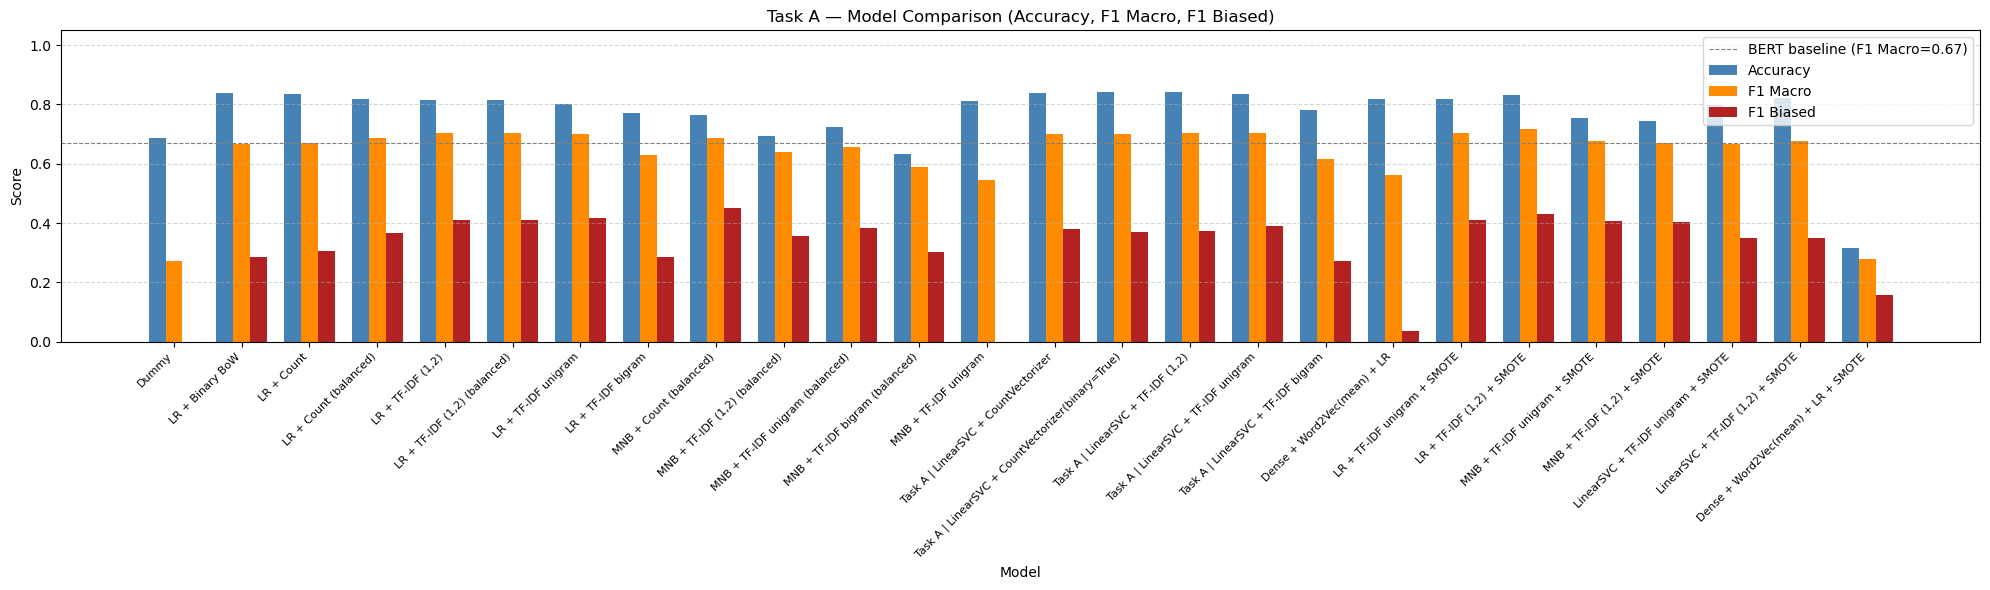

In [37]:
import matplotlib.pyplot as plt
import numpy as np

models    = list(results_a.keys())
accuracy  = [v['accuracy']  for v in results_a.values()]
f1_macro  = [v['f1_macro']  for v in results_a.values()]
f1_biased = [v['f1_biased'] for v in results_a.values()]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(20, 6))

ax.bar(x - width, accuracy,  width, label='Accuracy',  color='steelblue')
ax.bar(x,          f1_macro,  width, label='F1 Macro',  color='darkorange')
ax.bar(x + width,  f1_biased, width, label='F1 Biased', color='firebrick')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Task A — Model Comparison (Accuracy, F1 Macro, F1 Biased)')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right', fontsize=8)
ax.set_ylim(0, 1.05)
ax.axhline(y=0.67, color='gray', linestyle='--', linewidth=0.8, label='BERT baseline (F1 Macro=0.67)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('task_a_model_comparison.png', dpi=150)
plt.show()

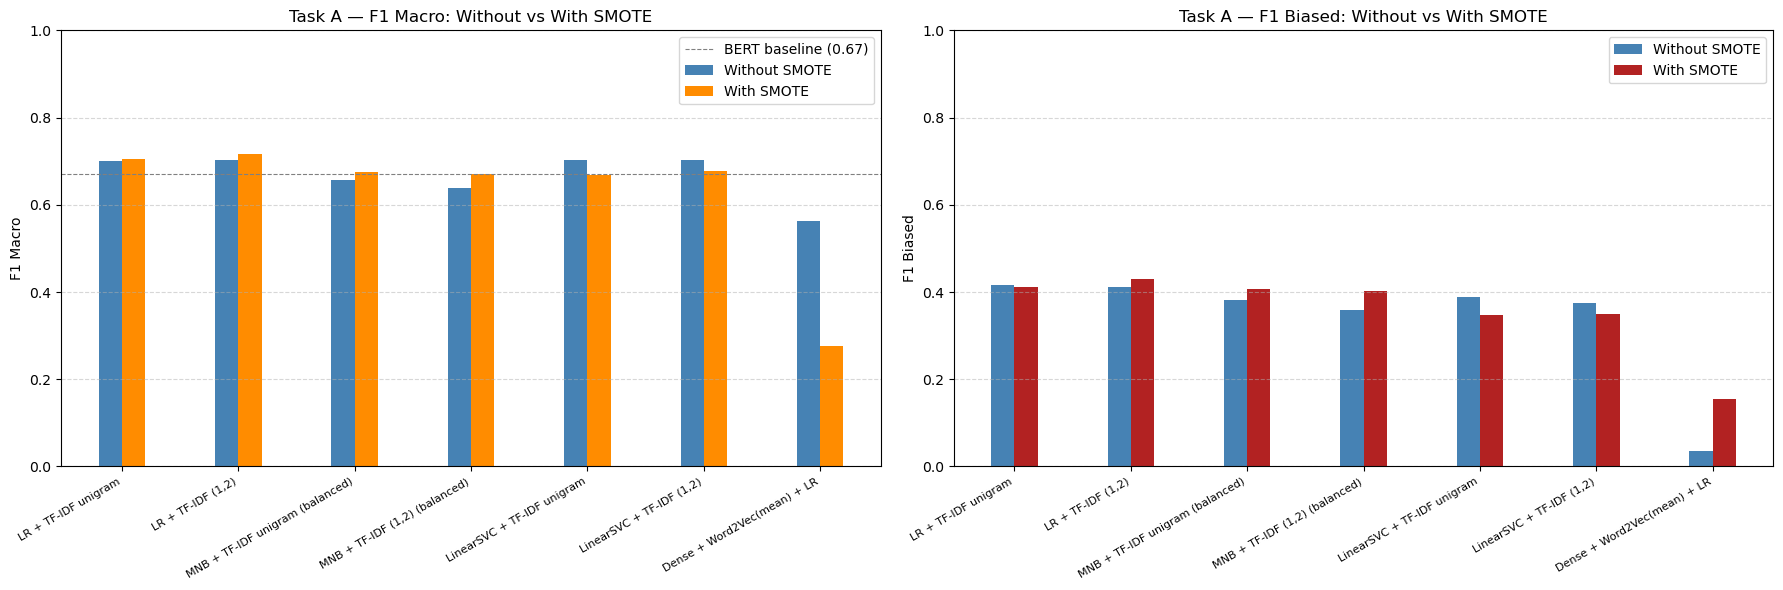

In [38]:

pairs = [
    ('LR + TF-IDF unigram',              'LR + TF-IDF unigram + SMOTE'),
    ('LR + TF-IDF (1,2)',                'LR + TF-IDF (1,2) + SMOTE'),
    ('MNB + TF-IDF unigram (balanced)',  'MNB + TF-IDF unigram + SMOTE'),
    ('MNB + TF-IDF (1,2) (balanced)',    'MNB + TF-IDF (1,2) + SMOTE'),
    ('Task A | LinearSVC + TF-IDF unigram', 'LinearSVC + TF-IDF unigram + SMOTE'),
    ('Task A | LinearSVC + TF-IDF (1,2)',   'LinearSVC + TF-IDF (1,2) + SMOTE'),
    ('Dense + Word2Vec(mean) + LR',         'Dense + Word2Vec(mean) + LR + SMOTE'),
]

labels       = [p[0].replace('Task A | ', '') for p in pairs]
f1_macro_base  = [results_a[p[0]]['f1_macro']  for p in pairs]
f1_macro_smote = [results_a[p[1]]['f1_macro']  for p in pairs]
f1_biased_base  = [results_a[p[0]]['f1_biased'] for p in pairs]
f1_biased_smote = [results_a[p[1]]['f1_biased'] for p in pairs]

x = np.arange(len(labels))
width = 0.2

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)


axes[0].bar(x - width/2, f1_macro_base,  width, label='Without SMOTE', color='steelblue')
axes[0].bar(x + width/2, f1_macro_smote, width, label='With SMOTE',    color='darkorange')
axes[0].axhline(y=0.67, color='gray', linestyle='--', linewidth=0.8, label='BERT baseline (0.67)')
axes[0].set_title('Task A — F1 Macro: Without vs With SMOTE')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('F1 Macro')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)


axes[1].bar(x - width/2, f1_biased_base,  width, label='Without SMOTE', color='steelblue')
axes[1].bar(x + width/2, f1_biased_smote, width, label='With SMOTE',    color='firebrick')
axes[1].set_title('Task A — F1 Biased: Without vs With SMOTE')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel('F1 Biased')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('task_a_smote_comparison.png', dpi=150)
plt.show()

### Observations

The Task A plots shows that **the hardest class is `biased`**, and this class is what limits macro-F1 the most.

- The **Dummy baseline** obtains high accuracy only because `factual` is the majority class, but it completely fails on `biased` and `quote`. This confirms that **accuracy alone is misleading** in this imbalanced setting.
- Among the traditional sparse models, the strongest overall behaviour comes from **LinearSVC** and **Logistic Regression** with lexical features, especially **CountVectorizer** and **TF-IDF** variants. These models keep strong performance on `factual` and `quote`, while still detecting at least part of the `biased` class.
- The **dense Word2Vec mean representation** is useful as a semantic baseline, but it is much weaker on `biased`. The report shows extremely low recall for `biased`, which suggests that averaging embeddings removes many of the lexical and stylistic cues that signal media bias.
- In practical terms, this means that **Task A is driven less by generic semantics and more by specific lexical framing cues**. Bias detection appears to benefit more from sparse representations that preserve explicit words and short phrases than from compact dense sentence averages.


### Task B: binary factuality design (`factual`, `non_factual`)

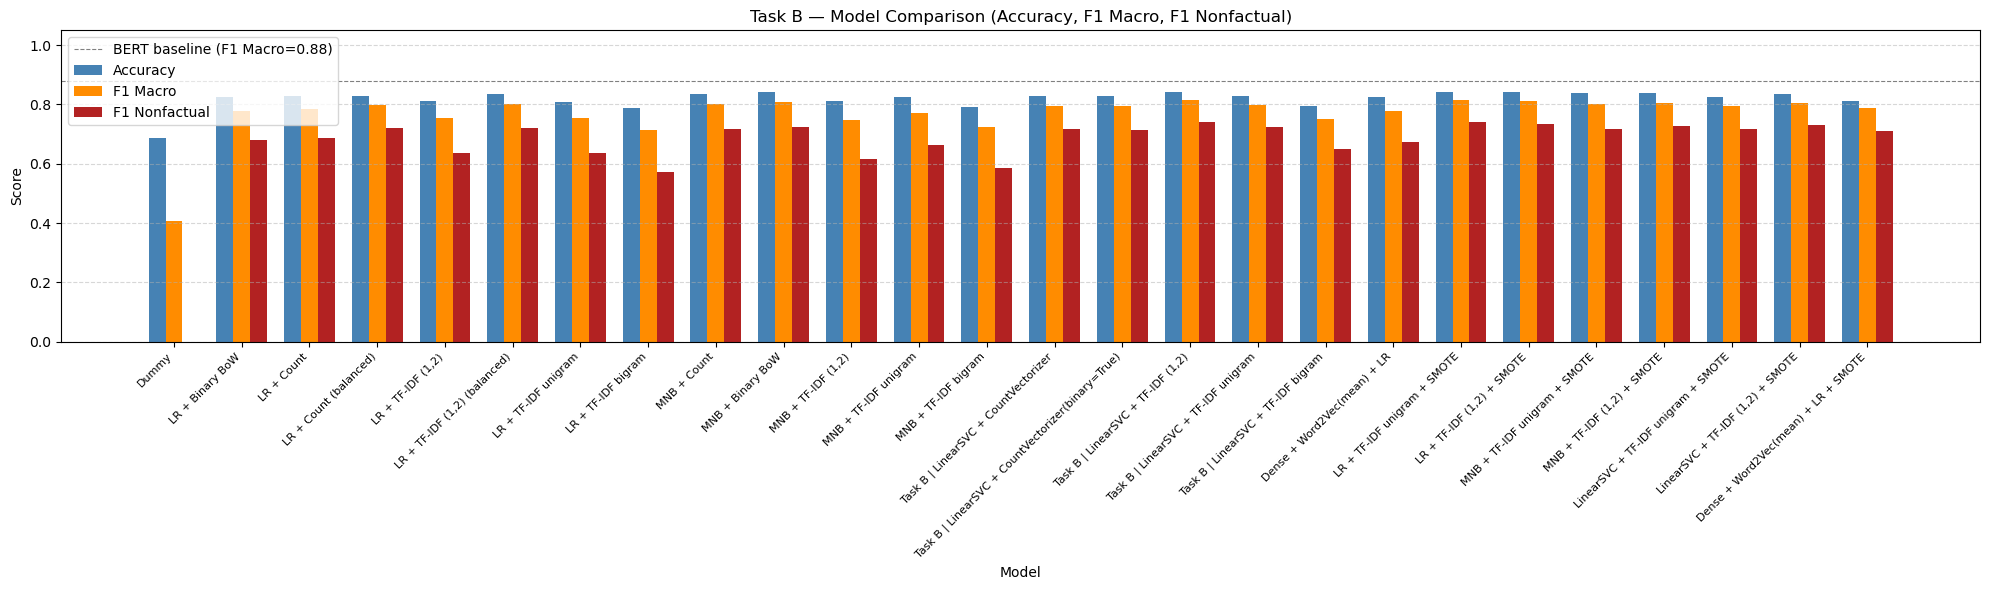

In [39]:
models       = list(results_b.keys())
accuracy     = [v['accuracy']      for v in results_b.values()]
f1_macro     = [v['f1_macro']      for v in results_b.values()]
f1_nonfactual = [v['f1_nonfactual'] for v in results_b.values()]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(20, 6))

ax.bar(x - width, accuracy,      width, label='Accuracy',       color='steelblue')
ax.bar(x,          f1_macro,      width, label='F1 Macro',       color='darkorange')
ax.bar(x + width,  f1_nonfactual, width, label='F1 Nonfactual',  color='firebrick')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Task B — Model Comparison (Accuracy, F1 Macro, F1 Nonfactual)')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right', fontsize=8)
ax.set_ylim(0, 1.05)
ax.axhline(y=0.88, color='gray', linestyle='--', linewidth=0.8, label='BERT baseline (F1 Macro=0.88)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('task_b_model_comparison.png', dpi=150)
plt.show()

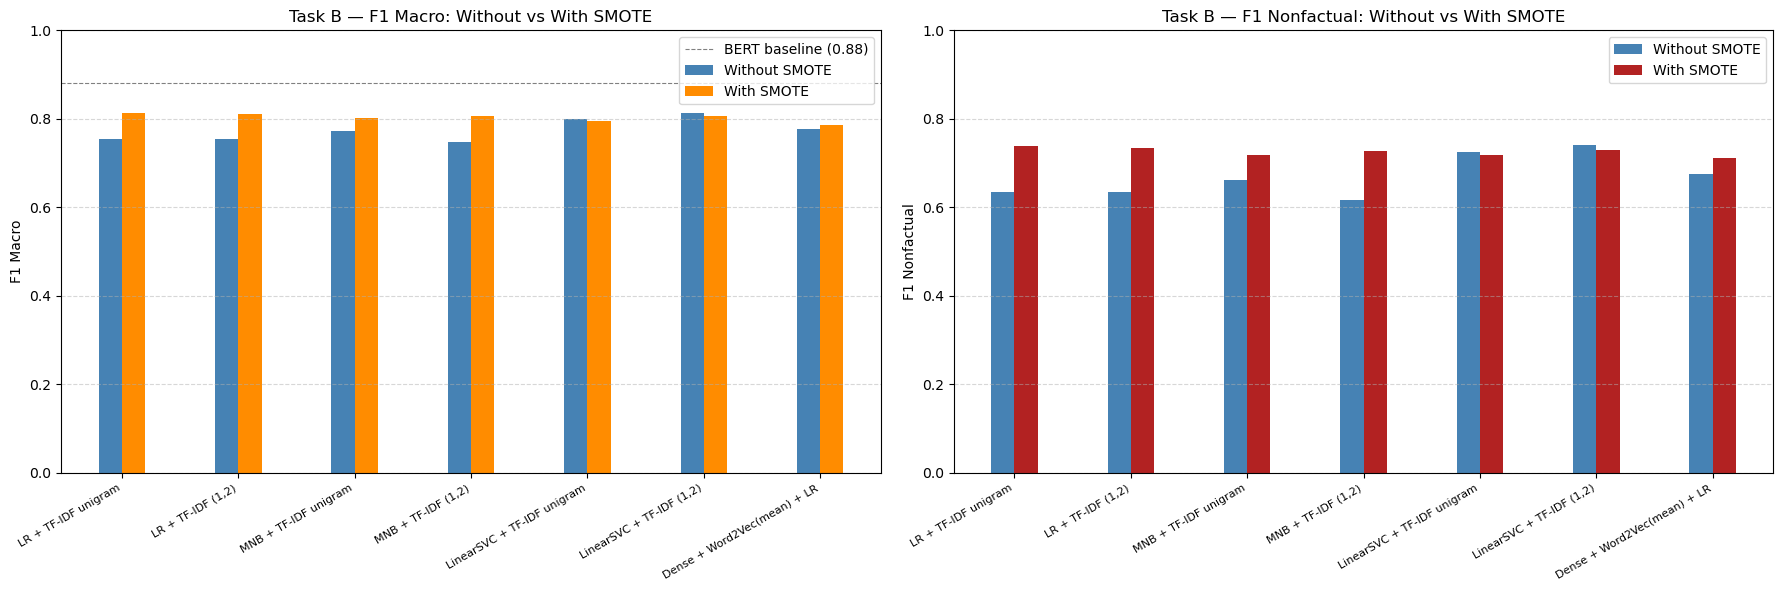

In [40]:
pairs_b = [
    ('LR + TF-IDF unigram',              'LR + TF-IDF unigram + SMOTE'),
    ('LR + TF-IDF (1,2)',                'LR + TF-IDF (1,2) + SMOTE'),
    ('MNB + TF-IDF unigram',             'MNB + TF-IDF unigram + SMOTE'),
    ('MNB + TF-IDF (1,2)',               'MNB + TF-IDF (1,2) + SMOTE'),
    ('Task B | LinearSVC + TF-IDF unigram', 'LinearSVC + TF-IDF unigram + SMOTE'),
    ('Task B | LinearSVC + TF-IDF (1,2)',   'LinearSVC + TF-IDF (1,2) + SMOTE'),
    ('Dense + Word2Vec(mean) + LR',         'Dense + Word2Vec(mean) + LR + SMOTE'),
]

labels_b            = [p[0].replace('Task B | ', '') for p in pairs_b]
f1_macro_base_b     = [results_b[p[0]]['f1_macro']       for p in pairs_b]
f1_macro_smote_b    = [results_b[p[1]]['f1_macro']       for p in pairs_b]
f1_nonfact_base_b   = [results_b[p[0]]['f1_nonfactual']  for p in pairs_b]
f1_nonfact_smote_b  = [results_b[p[1]]['f1_nonfactual']  for p in pairs_b]

x = np.arange(len(labels_b))
width = 0.2

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)


axes[0].bar(x - width/2, f1_macro_base_b,  width, label='Without SMOTE', color='steelblue')
axes[0].bar(x + width/2, f1_macro_smote_b, width, label='With SMOTE',    color='darkorange')
axes[0].axhline(y=0.88, color='gray', linestyle='--', linewidth=0.8, label='BERT baseline (0.88)')
axes[0].set_title('Task B — F1 Macro: Without vs With SMOTE')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_b, rotation=30, ha='right', fontsize=8)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('F1 Macro')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)


axes[1].bar(x - width/2, f1_nonfact_base_b,  width, label='Without SMOTE', color='steelblue')
axes[1].bar(x + width/2, f1_nonfact_smote_b, width, label='With SMOTE',    color='firebrick')
axes[1].set_title('Task B — F1 Nonfactual: Without vs With SMOTE')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_b, rotation=30, ha='right', fontsize=8)
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel('F1 Nonfactual')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('task_b_smote_comparison.png', dpi=150)
plt.show()

### Observations on the Task B graphs

Task B is easier than Task A because the problem is reduced to **`factual` vs `non_factual`**.

- The gap between the **Dummy baseline** and the trained models is already large, showing that the task is learnable with relatively simple traditional methods.
- The best-performing family is again the **sparse lexical models**, especially **LinearSVC + TF-IDF (1,2)** and the strongest Logistic Regression / MultinomialNB variants. These models achieve the best balance between overall accuracy and minority-class performance.
- Resampling helps mainly by **raising recall for `non_factual`**, which improves macro-F1. However, just like in Task A, this does not always produce the best absolute accuracy.
- The **dense Word2Vec mean baseline** remains competitive, but it still underperforms the best sparse models. This suggests that, in this dataset, exact lexical evidence and short local patterns remain more useful than averaged semantic similarity.
- Overall, the binary task confirms that **traditional ML can be quite strong when paired with good sparse features**, even without deep learning.


## Comparison with the paper

The original FactNews paper reports results obtained with transformer-based models, including BERT variants, which are outside the scope of this assignment.

The paper reports:
- **F1 = 0.67** for sentence-level media bias prediction with fine-tuned BERT
- **F1 = 0.88** for sentence-level factuality prediction with fine-tuned BERT

The main goal is **not** to beat the paper, but to understand how far strong non-neural baselines can go on the same problem, and to frame the traditional ML results in context:
- For **Task A (3-class classification)**, our best traditional models are competitive in macro-F1, but the difficulty remains concentrated on the `biased` class. .
- For **Task B (binary factuality)**, the gap to the paper becomes smaller. This is expected because the binary decision is simpler and easier for lexical models to capture.

Overall observations from the comparison:
1. The paper still sets a stronger upper bound, especially for the more nuanced bias-related task.
2. Even so, this notebook shows that **LinearSVC, Logistic Regression, and MultinomialNB remain strong baselines**.
3. The strongest gains in this notebook come from **feature engineering and class balancing**, not from model complexity alone.
4. The dense Word2Vec baseline is useful for comparison, but it does not match the best sparse configurations, suggesting that this dataset is driven more by **explicit lexical cues** than by broad semantic similarity.

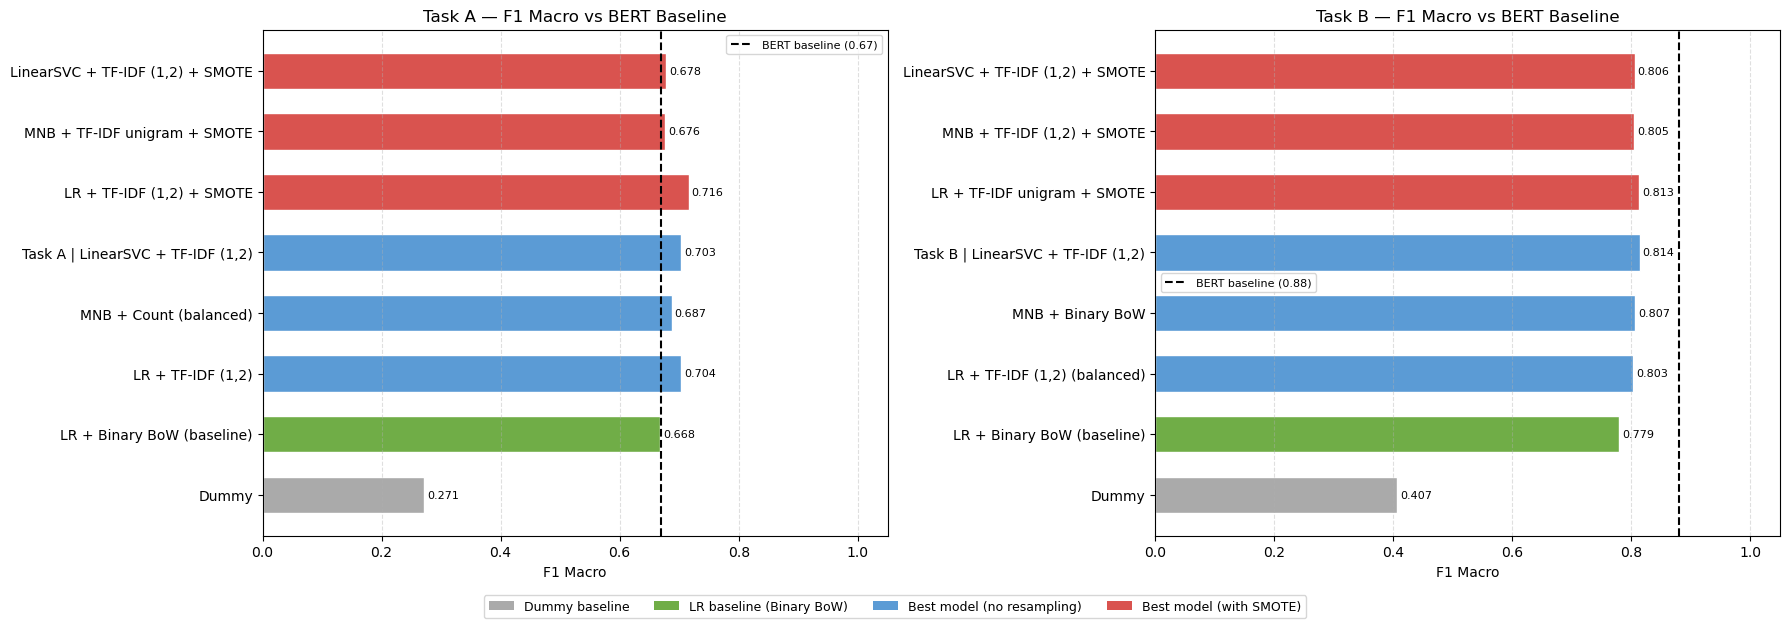

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, results, title, bert_baseline in [
    (axes[0], results_a, 'Task A — F1 Macro vs BERT Baseline', 0.67),
    (axes[1], results_b, 'Task B — F1 Macro vs BERT Baseline', 0.88),
]:
    def best_key(results, condition):
        return max(
            ((k, v['f1_macro']) for k, v in results.items() if condition(k)),
            key=lambda x: x[1]
        )[0]

    best_lr_key      = best_key(results, lambda k: 'LR' in k and 'SMOTE' not in k and 'Binary' not in k and 'baseline' not in k.lower())
    best_mnb_key     = best_key(results, lambda k: 'MNB' in k and 'SMOTE' not in k)
    best_svc_key     = best_key(results, lambda k: 'LinearSVC' in k and 'SMOTE' not in k)
    best_lr_smote    = best_key(results, lambda k: 'LR' in k and 'SMOTE' in k)
    best_mnb_smote   = best_key(results, lambda k: 'MNB' in k and 'SMOTE' in k)
    best_svc_smote   = best_key(results, lambda k: 'LinearSVC' in k and 'SMOTE' in k)

    data = {
        'Dummy':                        results['Dummy']['f1_macro'],
        'LR + Binary BoW (baseline)':   results['LR + Binary BoW']['f1_macro'],
        best_lr_key:                    results[best_lr_key]['f1_macro'],
        best_mnb_key:                   results[best_mnb_key]['f1_macro'],
        best_svc_key:                   results[best_svc_key]['f1_macro'],
        best_lr_smote:                  results[best_lr_smote]['f1_macro'],
        best_mnb_smote:                 results[best_mnb_smote]['f1_macro'],
        best_svc_smote:                 results[best_svc_smote]['f1_macro'],
    }

    labels = list(data.keys())
    values = list(data.values())

    colors = []
    for l in labels:
        if 'Dummy' in l:
            colors.append('#aaaaaa')
        elif 'baseline' in l.lower():
            colors.append('#70ad47')
        elif 'SMOTE' in l:
            colors.append('#d9534f')
        else:
            colors.append('#5b9bd5')

    bars = ax.barh(labels, values, color=colors, edgecolor='white', height=0.6)
    ax.axvline(x=bert_baseline, color='black', linestyle='--', linewidth=1.5,
               label=f'BERT baseline ({bert_baseline})')

    for bar, val in zip(bars, values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=8)

    ax.set_xlim(0, 1.05)
    ax.set_xlabel('F1 Macro')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#aaaaaa', label='Dummy baseline'),
    Patch(facecolor='#70ad47', label='LR baseline (Binary BoW)'),
    Patch(facecolor='#5b9bd5', label='Best model (no resampling)'),
    Patch(facecolor='#d9534f', label='Best model (with SMOTE)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           fontsize=9, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('best_model_vs_bert_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

## Error Analysis

The main source of error in this notebook is **class overlap**, especially in sentences that are short, ambiguous, or contain mixed signals.

### Task A (`biased`, `factual`, `quote`)

The most difficult class is clearly **`biased`**. This can be seen across several models:
- in many strong sparse models, `factual` and `quote` achieve high F1
- `biased` remains much lower, often because the model confuses it with `factual`

This happens for several reasons:

1. **Lexical overlap between factual and biased statements**  
   Many biased sentences still mention concrete events, named entities, or factual information. The difference is often not the topic itself, but the framing. Traditional models may detect the event words correctly while missing the subjective angle.

2. **Subtle framing cues**  
   Bias is often expressed through tone, emphasis, loaded adjectives, or selective wording. These cues may be weak compared with the stronger lexical evidence.

3. **Class imbalance**  
   The `biased` class is much smaller than `factual`, so many models initially optimize for the majority distribution. Resampling helps, but does not fully solve the problem.

4. **Dense averaging loses discriminative details**  
   The dense Word2Vec representation performs particularly poorly on `biased`, which suggests that averaging token embeddings removes the exact lexical markers that help identify slanted or opinionated language.

### Task B (`factual`, `non_factual`)

Task B is easier, but the main error pattern remains the same: the minority class `non_factual` is harder to recover than `factual`.

Reasons:
- `non_factual` includes different phenomena under the same label, such as bias-related and quote-related material
- some sentences contain both factual content and non-factual framing
- short sentences often provide too little context for a confident distinction

In the binary setup, sparse models already capture much of the needed signal, but they still tend to be more conservative and predict `factual` when evidence is mixed.

### Qualitative inspection

To make the error analysis more concrete, the following cell extracts misclassified examples from the strongest models, so that we can manually inspect what kinds of sentences are being confused.


In [42]:
def show_errors(texts, y_true, y_pred, title, max_rows=15):
    errors = pd.DataFrame({
        'text': np.array(texts),
        'true_label': np.array(y_true),
        'predicted_label': np.array(y_pred)
    })
    errors = errors[errors['true_label'] != errors['predicted_label']].copy()
    print(f"{title} — total errors: {len(errors)}")
    display(errors.head(max_rows))
    return errors

# Task A: inspect a strong sparse model
best_taskA_model = linearsvc_tfidf_a['best_model']
y_pred_taskA_best = best_taskA_model.predict(X_test_final_tfidf_a)
errors_taskA = show_errors(
    X_text_test_a.reset_index(drop=True),
    y_test_a.reset_index(drop=True),
    y_pred_taskA_best,
    title="Task A | LinearSVC + TF-IDF (1,2)"
)

# Task B: inspect a strong sparse model
best_taskB_model = linearsvc_tfidf_b['best_model']
y_pred_taskB_best = best_taskB_model.predict(X_test_final_tfidf_b)
errors_taskB = show_errors(
    X_text_test_b.reset_index(drop=True),
    y_test_b.reset_index(drop=True),
    y_pred_taskB_best,
    title="Task B | LinearSVC + TF-IDF (1,2)"
)

Task A | LinearSVC + TF-IDF (1,2) — total errors: 196


,text,true_label,predicted_label
19,em um dos massacres mais mortais da história d...,biased,factual
21,a ascensão de meloni oriunda de um partido lig...,factual,biased
26,"""foi olhando para frente que a premiê do reino...",quote,factual
31,"""ele deveria prestar atenção na fumaça e nas f...",quote,factual
37,a defesa conduziu durante o primeiro turno das...,factual,quote
48,"na ocasião disse que ""sempre combateu a pedofi...",quote,factual
53,veja também 'renúncia de deputado da pb é escá...,quote,factual
55,"o estado de são paulo"" e confirmado pela tv globo",factual,quote
65,já capixaba acusado de ter recebido r mil cons...,biased,factual
68,elas são desenhadas para não matar embora even...,biased,quote


Task B | LinearSVC + TF-IDF (1,2) — total errors: 195


,text,true_label,predicted_label
14,o grupo tem chamado atenção e recebido crítica...,factual,non_factual
19,a evidência preliminar sugere um risco aumenta...,factual,non_factual
20,no brasil foi recentemente publicado sempre pe...,factual,non_factual
40,cada vez mais questionada por suas decisões po...,non_factual,factual
41,jorge larrionda não marcou o pênalti para o eq...,factual,non_factual
44,a menos de dias das eleições a tesourada acend...,non_factual,factual
45,o brasil novamente se absteve salvo exceções p...,factual,non_factual
50,bolsonaro agradeceu o apoio dos cantores que d...,non_factual,factual
56,já o senador aloizio mercadante pt sp não tem ...,non_factual,factual
58,disse ariovaldo ramos,non_factual,factual


## Conclusion

This notebook implements a complete traditional-machine-learning pipeline for the FactNews dataset:
- dataset understanding and EDA
- text pre-processing
- sparse and dense feature representations
- baseline and competitive classifiers
- evaluation with appropriate metrics
- additional resampling analysis


The experiments support several final conclusions.

First, simple baselines are not enough for this task. The Dummy classifier achieves acceptable accuracy only because of class imbalance, but it fails on the minority classes. This confirms that macro-F1 and class-specific F1 are much more informative than accuracy alone.

Second, the strongest results come from traditional sparse lexical models, especially **LinearSVC**, **Logistic Regression**, and **Multinomial Naive Bayes** combined with **CountVectorizer** or **TF-IDF** features.

Third, the **dense Word2Vec(mean) representation** is a useful comparison point, but it is not the strongest solution in this setting. 

Fourth, in several cases resampling improves recall on minority classes such as `biased` and `non_factual`, which raises macro-F1. However, this sometimes comes at the cost of reduced accuracy or lower precision. This means resampling should be treated as a targeted tool for imbalance, not as an automatic improvement.

Fifth, the results show a clear difference between the two tasks:
- **Task A (3-class classification)** is substantially harder because the `biased` class is subtle, small, and often overlaps lexically with `factual`
- **Task B (binary factuality)** is easier, and traditional models come closer to the reference results from the original paper

Overall, the main takeaway is that traditional NLP pipelines still provide meaningful performance on FactNews. Even without CNNs, RNNs, or Transformers, it is possible to build solid classifiers, understand their limitations, and produce a well-grounded analysis of what drives performance on this dataset.
